# FITE Classification Challenge


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

في هذا المشروع بنينا نظام تصنيف متعدد الكلاسات لبيانات مجهولة الأعمدة. كل صف يحتوي على 21 خاصية مرمزة من `f1` إلى `f21`، والمطلوب توقع قيمة `target` في ملف الاختبار.

التحدي الأساسي ليس تنظيف نصوص أو فهم معنى الأعمدة، لأن الأعمدة anonymized، بل اكتشاف الأنماط من الأرقام نفسها بدون افتراضات خارجية. لذلك بدأنا بتحليل إحصائي للداتا، ثم بنينا نماذج متعددة، وبعدها قارناها باستخدام تحقق داخلي واضح.

اعتمدنا `Macro F1` كمقياس أساسي لأن الداتا غير متوازنة: الكلاس الأكبر يسيطر على أغلب الصفوف، بينما `class1` و`class2` أقل بكثير. هذا يجعل Accuracy وحدها غير كافية، لأن النموذج قد يبدو ممتازاً وهو فعلياً ضعيف على الكلاسات الصغيرة.

كل التنبؤات في `submission.csv` ناتجة من نماذج مدربة على `train_data.csv` فقط. لم نستخدم labels من الاختبار، ولم نطبق تعديلات صف-بصف على ملف الرفع.

</div>


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 1. تجهيز المكتبات والإعدادات

نبدأ بتجهيز المكتبات والثوابت المستخدمة في التحليل والتدريب. أهم شيء هنا هو تثبيت `RANDOM_STATE` حتى تكون تقسيمات التحقق ونتائج النماذج قابلة للإعادة قدر الإمكان.

استخدمنا مكتبات للتحليل مثل `pandas` و`matplotlib`، ومكتبات للتقييم مثل `LabelEncoder` و`ConfusionMatrixDisplay`. هذه الخلية تجهز البيئة فقط؛ التدريب الفعلي يبدأ بعد قراءة الداتا وفهم شكلها.

</div>


In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.metrics import ConfusionMatrixDisplay

RANDOM_STATE = 42
TRAIN_FILE = "train_data.csv"
TEST_FILE = "test_data.csv"
SAMPLE_FILE = "sample_submission.csv"
ARTIFACT_DIR = Path("classification_artifacts")

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 2. قراءة الداتا وفحص الشكل العام

قرأنا ملفات `train_data.csv` و`test_data.csv` و`sample_submission.csv`. بيانات التدريب تحتوي على 3200 صف و23 عموداً: عمود `ID`، و21 خاصية، وعمود الهدف `target`. بيانات الاختبار تحتوي على 3200 صف و22 عموداً لأنها لا تحتوي على `target`.

فحصنا أن أعمدة الخصائص في train وtest متطابقة، وأن ترتيب `ID` في `sample_submission.csv` مطابق لترتيب `test_data.csv`. هذا مهم لأن ملف الرفع يجب أن يحافظ على نفس ترتيب الصفوف.

وجدنا أن الداتا لا تحتوي على missing values، لذلك لم نحتج إلى imputation. بالمقابل، وجدنا بعض الصفوف المكررة حسب الخصائص، وهذا منطقي في بيانات anonymized وقد يكون جزءاً من النمط، لذلك لم نحذفها عشوائياً.

</div>


In [2]:
train = pd.read_csv(TRAIN_FILE)
test = pd.read_csv(TEST_FILE)
sample_submission = pd.read_csv(SAMPLE_FILE)

ID_COL = "ID"
TARGET_COL = "target"
feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET_COL]]

assert TARGET_COL in train.columns
assert TARGET_COL not in test.columns
assert feature_cols == [c for c in test.columns if c != ID_COL]
assert sample_submission[ID_COL].tolist() == test[ID_COL].tolist()

basic_checks = pd.DataFrame({
    "الفحص": [
        "شكل train", "شكل test", "عدد الخصائص", "القيم المفقودة في train", "القيم المفقودة في test",
        "ID فريد في train", "ID فريد في test", "صفوف مكررة حسب الخصائص في train", "صفوف مكررة حسب الخصائص في test"
    ],
    "القيمة": [
        train.shape, test.shape, len(feature_cols), int(train.isna().sum().sum()), int(test.isna().sum().sum()),
        bool(train[ID_COL].is_unique), bool(test[ID_COL].is_unique), int(train[feature_cols].duplicated().sum()), int(test[feature_cols].duplicated().sum())
    ]
})

display(basic_checks)
display(train.head())
display(test.head())

,الفحص,القيمة
0,شكل train,"(3200, 23)"
1,شكل test,"(3200, 22)"
2,عدد الخصائص,21
3,القيم المفقودة في train,0
4,القيم المفقودة في test,0
5,ID فريد في train,True
6,ID فريد في test,True
7,صفوف مكررة حسب الخصائص في train,57
8,صفوف مكررة حسب الخصائص في test,7


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,target
0,1,0.38,0.0160,0,0,0,0,0,0,0.10800,0.00088,0,0,0,0.12700,0,1,0,0,0,0.085,0,class3
1,2,0.37,0.0250,0,0,0,0,0,0,0.08400,0.00510,0,0,0,0.08000,0,0,0,0,0,0.104,0,class3
2,3,0.57,0.0220,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,class3
3,4,0.54,0.0206,0,1,0,0,0,0,0.10100,0.00020,0,1,0,0.15800,0,0,0,0,0,0.064,0,class3
4,5,0.42,0.0208,0,0,0,0,0,0,0.12300,0.00720,0,0,0,0.10400,0,0,0,0,0,0.116,0,class2


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21
0,10000,0.57,0.023,0,1,0,0,0,0,0.115,0.00600,0,1,1,0.11954,0,0,0,0,0,0.096,0
1,10001,0.54,0.013,1,0,0,0,0,0,0.102,0.00085,0,0,0,0.11300,0,0,0,0,0,0.091,0
2,10002,0.56,0.019,0,1,0,0,0,0,0.096,0.00097,0,0,0,0.10300,0,0,0,0,0,0.093,0
3,10003,0.26,0.023,1,0,0,0,0,0,0.096,0.00110,0,0,0,0.12300,0,0,0,0,0,0.078,0
4,10004,0.60,0.023,0,1,1,0,0,0,0.155,0.00004,0,1,0,0.22100,0,0,0,1,0,0.070,0


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا فهمنا من فحص الداتا؟

الداتا نظيفة من ناحية القيم المفقودة وتطابق الأعمدة، وهذا يقلل خطر الأخطاء الشكلية. الصعوبة الحقيقية ظهرت في نقطتين: عدم توازن الكلاسات، ووجود أنماط رقمية قوية داخل بعض الخصائص.

عدم حذف الصفوف المكررة كان قراراً مقصوداً: بما أن الخصائص مجهولة، لا يوجد دليل أن التكرار خطأ. في التصنيف، التكرار أحياناً يمثل نمطاً حقيقياً للكلاس الأكثر انتشاراً.

</div>


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 3. توزيع الكلاسات واختيار معيار التقييم

توزيع الهدف غير متوازن بشكل واضح: `class3` تمثل 2916 صفاً من أصل 3200، أي حوالي 91.12%. بالمقابل `class2` تمثل 5.97%، و`class1` تمثل 2.91% فقط.

لهذا السبب لا تكفي Accuracy وحدها. نموذج يتنبأ غالباً بـ `class3` قد يحصل على Accuracy عالية، لكنه يفشل في `class1` و`class2`. لذلك استخدمنا `Macro F1` لأنه يحسب F1 لكل كلاس ثم يأخذ المتوسط، فيعطي الكلاسات الصغيرة حقها في التقييم.

استخدمنا أيضاً `Balanced Accuracy` و`confusion matrix` حتى نرى أين تحدث الأخطاء، وليس فقط رقماً واحداً عاماً.

</div>


,count,percentage
target,,
class1,93,2.906
class2,191,5.969
class3,2916,91.125


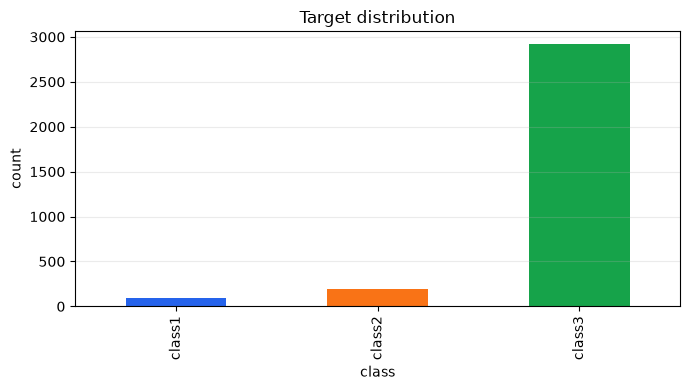

In [3]:
target_counts = train[TARGET_COL].value_counts().sort_index()
target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": (target_counts / len(train) * 100).round(3)
})
display(target_distribution)

fig, ax = plt.subplots(figsize=(7, 4))
target_counts.plot(kind="bar", ax=ax, color=["#2563eb", "#f97316", "#16a34a"])
ax.set_title("Target distribution")
ax.set_xlabel("class")
ax.set_ylabel("count")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا استنتجنا من توزيع الهدف؟

المشكلة ليست أن نعرف الكلاس الأكبر فقط، بل أن نلتقط الإشارات التي تميز `class1` و`class2`. لذلك استخدمنا `StratifiedKFold` حتى تبقى نسب الكلاسات داخل كل fold قريبة من التوزيع الأصلي.

كما استخدمنا `class_weight='balanced'` في النماذج التي تدعمه. الهدف من ذلك تقليل انحياز النموذج للكلاس الأكبر، ورفع حساسيته للكلاسات الأقل ظهوراً.

</div>


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 4. فهم أنواع الخصائص

بما أن أسماء الخصائص مجهولة، تعاملنا معها حسب سلوكها الإحصائي لا حسب معناها. وجدنا 15 خاصية ثنائية قيمها 0/1، و6 خصائص مستمرة هي `f1`, `f2`, `f9`, `f10`, `f14`, `f20`.

هذا التقسيم ساعدنا في بناء خصائص عامة: عدد القيم الثنائية المفعلة في الصف، تفاعلات بين الخصائص المستمرة، ومؤشرات للقيم الطرفية. هذه التحويلات لا تحتاج معرفة معنى الأعمدة، لذلك تبقى مناسبة للداتا anonymized.

</div>


In [4]:
binary_features = []
continuous_features = []
for c in feature_cols:
    train_values = set(train[c].dropna().unique())
    test_values = set(test[c].dropna().unique())
    if train_values.issubset({0, 1, 0.0, 1.0}) and test_values.issubset({0, 1, 0.0, 1.0}):
        binary_features.append(c)
    else:
        continuous_features.append(c)

feature_type_df = pd.DataFrame({
    "feature": feature_cols,
    "type": ["binary" if c in binary_features else "continuous" for c in feature_cols],
    "train_nunique": [train[c].nunique() for c in feature_cols],
    "test_nunique": [test[c].nunique() for c in feature_cols],
    "train_mean": [train[c].mean() for c in feature_cols],
    "test_mean": [test[c].mean() for c in feature_cols],
})
feature_type_df["abs_mean_diff"] = (feature_type_df["train_mean"] - feature_type_df["test_mean"]).abs()

display(feature_type_df.sort_values(["type", "abs_mean_diff"], ascending=[True, False]))
print("Binary:", binary_features)
print("Continuous:", continuous_features)

,feature,type,train_nunique,test_nunique,train_mean,test_mean,abs_mean_diff
17,f18,binary,2,2,0.059375,0.077188,0.017813
11,f12,binary,2,2,0.122813,0.139375,0.016562
6,f7,binary,2,2,0.005000,0.020938,0.015938
12,f13,binary,2,2,0.061875,0.069687,0.007812
7,f8,binary,2,2,0.012188,0.018437,0.006250
20,f21,binary,2,2,0.013437,0.007500,0.005938
4,f5,binary,2,2,0.014687,0.019062,0.004375
14,f15,binary,2,2,0.011250,0.014063,0.002813
2,f3,binary,2,2,0.045000,0.046562,0.001563
5,f6,binary,2,2,0.038750,0.037187,0.001563


Binary: ['f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f11', 'f12', 'f13', 'f15', 'f16', 'f17', 'f18', 'f19', 'f21']
Continuous: ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا استنتجنا من أنواع الخصائص؟

الداتا رقمية بالكامل ولا تحتاج one-hot encoding للنصوص. وجود خصائص ثنائية كثيرة مع خصائص مستمرة قليلة يجعل نماذج الأشجار مناسبة جداً، لأنها تستطيع بناء شروط مثل: قيمة مستمرة أعلى من حد معين مع خاصية ثنائية مساوية للصفر.

هذا يفسر لماذا ظهرت نماذج Decision Tree وRandom Forest وBoosting قوية في النتائج.

</div>


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 5. مقارنة توزيع Train و Test

قارننا متوسط كل خاصية بين train وtest حتى نتأكد أن توزيع الاختبار ليس مختلفاً جذرياً عن التدريب. أكبر فروقات ظهرت في `f18`, `f12`, `f7`, `f1`, و`f13`، لكنها بقيت صغيرة نسبياً؛ أكبر فرق كان حوالي 0.0178.

هذا الفحص لا يستخدم `target` من الاختبار ولا يغير التنبؤات. دوره فقط كشف وجود اختلاف distribution shift كبير من عدمه.

</div>


,feature,type,train_mean,test_mean,abs_mean_diff
17,f18,binary,0.059375,0.077188,0.017813
11,f12,binary,0.122813,0.139375,0.016562
6,f7,binary,0.005000,0.020938,0.015938
0,f1,continuous,0.516861,0.526824,0.009963
12,f13,binary,0.061875,0.069687,0.007812
13,f14,continuous,0.109880,0.116732,0.006852
7,f8,binary,0.012188,0.018437,0.006250
20,f21,binary,0.013437,0.007500,0.005938
4,f5,binary,0.014687,0.019062,0.004375
8,f9,continuous,0.107968,0.110992,0.003023


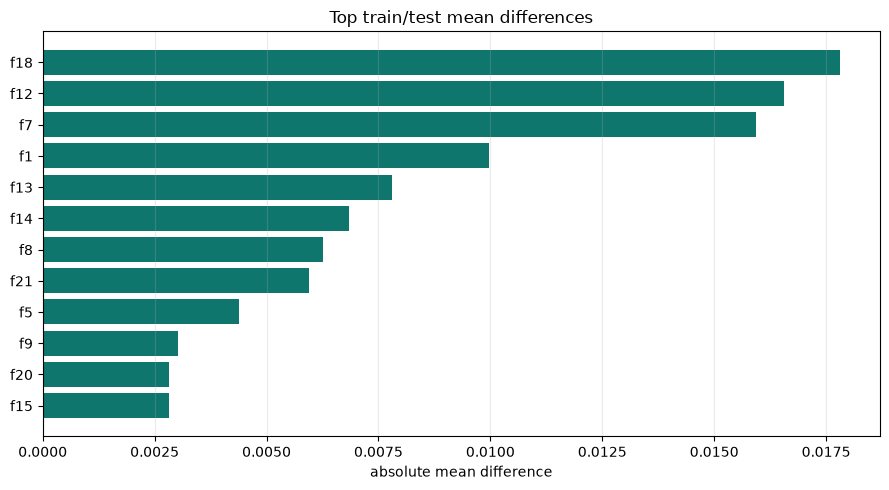

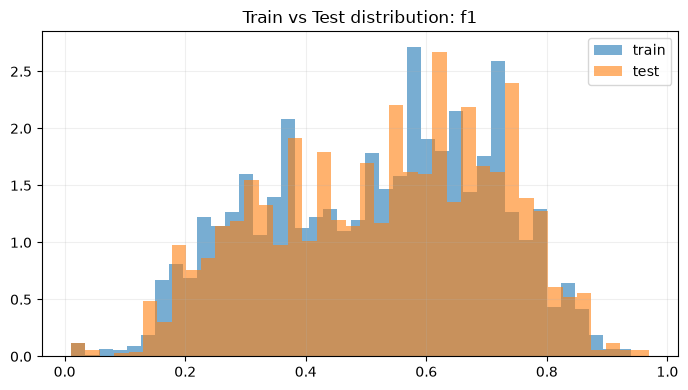

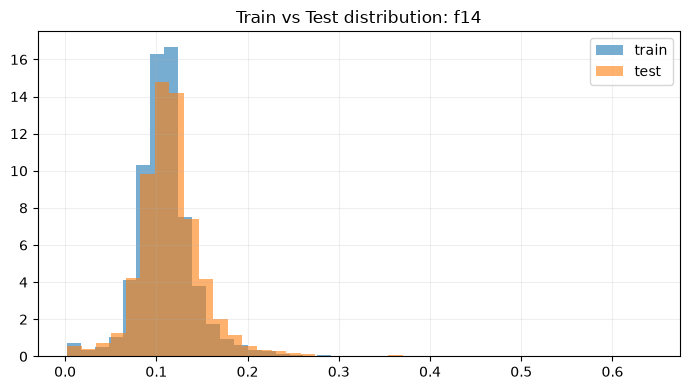

In [5]:
drift_df = feature_type_df.sort_values("abs_mean_diff", ascending=False)
display(drift_df[["feature", "type", "train_mean", "test_mean", "abs_mean_diff"]].head(12))

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = drift_df.head(12).iloc[::-1]
ax.barh(plot_df["feature"], plot_df["abs_mean_diff"], color="#0f766e")
ax.set_title("Top train/test mean differences")
ax.set_xlabel("absolute mean difference")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

for c in [x for x in drift_df["feature"].head(6) if x in continuous_features]:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(train[c], bins=40, alpha=0.6, density=True, label="train")
    ax.hist(test[c], bins=40, alpha=0.6, density=True, label="test")
    ax.set_title(f"Train vs Test distribution: {c}")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا استنتجنا من مقارنة Train و Test؟

التوزيع العام بين train وtest متقارب، لذلك التحقق الداخلي عندنا له معنى. لكن وجود Private split يعني أن الاعتماد على نتيجة Public فقط قد يكون مضللاً.

لهذا السبب ركزنا على نتائج Cross-Validation، وعلى إعادة التقييم بأكثر من `random_state`، حتى لا يكون اختيار النموذج مبنياً على تقسيم واحد محظوظ.

</div>


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 6. أهمية الخصائص من بيانات التدريب

استخدمنا `Mutual Information` و`ANOVA F-score` على بيانات التدريب فقط لمعرفة الخصائص الأكثر ارتباطاً بالهدف. أقوى الإشارات ظهرت في `f10`, `f14`, `f9`, و`f2`، ثم ظهرت بعض الخصائص الثنائية مثل `f12` و`f13` بإشارة أصغر لكنها مهمة.

هذه النتيجة وجهت هندسة الخصائص: لم نضف خصائص عشوائية كثيرة، بل ركزنا على تفاعلات عامة بين الأعمدة المستمرة، وعلى تلخيص الخصائص الثنائية.

</div>


,feature,type,mutual_information,anova_f_score,anova_pvalue
9,f10,continuous,0.281781,991.761826,0.000000e+00
13,f14,continuous,0.137953,331.484714,1.502435e-131
8,f9,continuous,0.108202,283.363477,5.076408e-114
1,f2,continuous,0.092057,117.512854,5.669935e-50
11,f12,binary,0.020573,14.852188,3.798027e-07
12,f13,binary,0.012737,14.289268,6.634724e-07
0,f1,continuous,0.012244,0.572002,5.644521e-01
16,f17,binary,0.009627,1.553742,2.116149e-01
19,f20,continuous,0.009546,3.082477,4.598183e-02
15,f16,binary,0.004152,1.177318,3.082374e-01


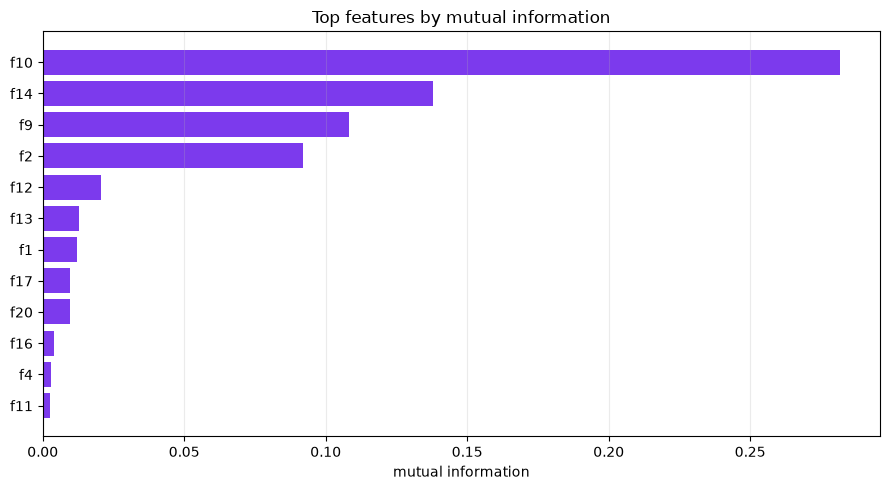

In [6]:
le = LabelEncoder()
y_encoded = le.fit_transform(train[TARGET_COL])
class_names = list(le.classes_)

mi_scores = mutual_info_classif(train[feature_cols], y_encoded, random_state=RANDOM_STATE)
f_scores, f_pvalues = f_classif(train[feature_cols], y_encoded)
feature_score_df = pd.DataFrame({
    "feature": feature_cols,
    "type": ["binary" if c in binary_features else "continuous" for c in feature_cols],
    "mutual_information": mi_scores,
    "anova_f_score": f_scores,
    "anova_pvalue": f_pvalues,
}).sort_values("mutual_information", ascending=False)

display(feature_score_df)

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = feature_score_df.head(12).iloc[::-1]
ax.barh(plot_df["feature"], plot_df["mutual_information"], color="#7c3aed")
ax.set_title("Top features by mutual information")
ax.set_xlabel("mutual information")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا استنتجنا من أهمية الخصائص؟

`f10` كان أقوى feature حسب Mutual Information، وبعده `f14`. هذا يعني أن جزءاً كبيراً من الفصل بين الكلاسات موجود في حدود رقمية واضحة، وليس في كل الأعمدة بالتساوي.

وجود `f12` بين الخصائص المهمة رغم أنها binary أظهر أن بعض الشروط البسيطة قد تكون قوية جداً، مثل تفاعل قيمة `f10` العالية مع `f12 = 0`. هذا ظهر لاحقاً أيضاً في قواعد شجرة القرار الخام.

</div>


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 7. بناء منهجية الحل

بنينا الحل على مراحل بدل القفز مباشرة إلى نموذج واحد. أولاً جربنا نماذج بسيطة حتى نعرف قوة الإشارة الموجودة في الداتا. بعدها جربنا نماذج أقوى مثل Random Forest وExtra Trees وGradient Boosting وLightGBM/XGBoost عند توفرها.

بعد ذلك استخدمنا ensemble احتمالي: كل نموذج يعطي احتمالات للكلاسات، ثم ندمج الاحتمالات بأوزان. الفكرة أن النماذج قد تكون متقاربة في الأداء لكنها تخطئ في صفوف مختلفة، والدمج يقلل الاعتماد على قرار نموذج واحد.

كل الاختيارات تمت بناءً على `Macro F1` ونتائج OOF، مع فحص إضافي للثبات عبر أكثر من تقسيم.

</div>


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 8. تشغيل الـ Pipeline داخل النوتبوك

هذه النسخة من النوتبوك مستقلة: الكود التدريبي موجود هنا مقسماً إلى خلايا، والملف `classification_pipeline.py` يحتوي نسخة برمجية مطابقة يمكن تشغيلها من الطرفية.

الـ pipeline ينفذ الخطوات التالية بالترتيب: قراءة الداتا، فحص train/test drift، بناء الخصائص، تدريب النماذج، حساب OOF predictions، تسجيل التجارب في MLflow، توثيق baselines، فحص الثبات، اختبار أوزان الـ ensemble على holdout داخلي، حفظ احتمالات OOF لكل صف، ثم توليد `submission.csv`.

وجود النسختين `.ipynb` و`.py` مقصود: النوتبوك للشرح والتحليل، والملف البرمجي للتشغيل المباشر وإعادة الإنتاج.

</div>


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.1 إعدادات الـ Pipeline والاستيرادات

هذه الخلية تجمع الاستيرادات والثوابت الخاصة بالتدريب. وضعنا أسماء الملفات، عدد folds، إعدادات ensemble، ومسار artifacts في مكان واحد حتى يكون تعديل التجربة واضحاً ومنضبطاً.

الخلية أيضاً تحتوي قائمة الحماية المنهجية داخل الكود: لا يوجد استخدام لملف قيم حقيقية للاختبار، ولا تعديلات يدوية على الصفوف، ولا lookup من خارج بيانات التدريب.

</div>


In [7]:
"""Clean, reproducible pipeline for the FITE Classification Challenge.

What this script does:
- Reads train_data.csv, test_data.csv, sample_submission.csv.
- Performs train-only feature engineering through a sklearn Transformer.
- Evaluates several models with StratifiedKFold validation.
- Logs all experiments to MLflow when available, otherwise to a CSV fallback.
- Builds a probability ensemble from out-of-fold validation results.
- Saves exactly one submission file: submission.csv.

Academic integrity:
- No true_values.csv usage.
- No test labels.
- No leaderboard probing.
- No row-specific overrides.
"""

from __future__ import annotations

import json
import os
import random
import warnings
from dataclasses import dataclass
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore")


RANDOM_STATE = 42
N_SPLITS = 5
USE_REFERENCE_ENSEMBLE_CANDIDATE = True
REFERENCE_ENSEMBLE_F1_TOLERANCE = 0.0011
TRAIN_FILE = "train_data.csv"
TEST_FILE = "test_data.csv"
SAMPLE_FILE = "sample_submission.csv"
OUTPUT_FILE = "submission.csv"
EXPERIMENT_LOG_FILE = "classification_experiment_log.csv"
ARTIFACT_DIR = Path("classification_artifacts")
ROBUST_VALIDATION_SEEDS = [7, 42, 123]
BLENDING_HOLDOUT_SEEDS = [7, 42, 123, 2026, 2027]
STABLE_ENSEMBLE_F1_TOLERANCE = 0.0020


def set_all_seeds(seed: int = RANDOM_STATE) -> None:
    np.random.seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)



<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.2 تثبيت العشوائية و Feature Engineering العام

هذه الخلية تبني `ClassificationFeatureBuilder`. بما أن الخصائص مجهولة، اعتمدنا هندسة خصائص حيادية: تفاعلات بين الأعمدة المستمرة، نسب وفروق، عدد الخصائص الثنائية المفعلة، ومؤشرات للقيم الطرفية حسب quantiles محسوبة من train فقط.

استخدام quantiles يتم داخل `fit` على بيانات التدريب في كل fold، ثم يطبق على validation/test. بهذه الطريقة لا نسمح لمعلومات validation أن تدخل في تجهيز الخصائص.

</div>


In [8]:
class ClassificationFeatureBuilder(BaseEstimator, TransformerMixin):
    """Train-only generic feature engineering for anonymized tabular data.

    Since feature meanings are hidden, the transformations are intentionally
    domain-neutral: interactions among continuous features, binary counts, rare
    binary counts, and train-quantile outlier indicators.
    """

    def __init__(self, outlier_quantiles: tuple[float, float] = (0.01, 0.99), rare_threshold: float = 0.02):
        self.outlier_quantiles = outlier_quantiles
        self.rare_threshold = rare_threshold

    def fit(self, X: pd.DataFrame, y=None):
        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = list(X.columns)
        self.binary_cols_ = []
        self.cont_cols_ = []
        for col in self.feature_names_in_:
            vals = set(pd.Series(X[col]).dropna().unique())
            if vals.issubset({0, 1, 0.0, 1.0}):
                self.binary_cols_.append(col)
            else:
                self.cont_cols_.append(col)

        q_low, q_high = self.outlier_quantiles
        self.low_quantiles_ = X[self.cont_cols_].quantile(q_low).to_dict()
        self.high_quantiles_ = X[self.cont_cols_].quantile(q_high).to_dict()
        self.rare_binary_cols_ = [col for col in self.binary_cols_ if float(X[col].mean()) < self.rare_threshold]
        return self

    def transform(self, X: pd.DataFrame):
        X = pd.DataFrame(X).copy()
        X = X[self.feature_names_in_]
        out = X.copy()

        eps = 1e-6
        for col in self.cont_cols_:
            out[f"{col}_sq"] = X[col] ** 2
            out[f"{col}_sqrt"] = np.sqrt(np.clip(X[col], 0, None))
            out[f"{col}_below_q01"] = (X[col] < self.low_quantiles_[col]).astype(int)
            out[f"{col}_above_q99"] = (X[col] > self.high_quantiles_[col]).astype(int)

        # Generic pairwise interactions for continuous variables.
        for i, a in enumerate(self.cont_cols_):
            for b in self.cont_cols_[i + 1 :]:
                out[f"{a}_x_{b}"] = X[a] * X[b]
                out[f"{a}_minus_{b}"] = X[a] - X[b]
                out[f"{a}_div_{b}"] = X[a] / (np.abs(X[b]) + eps)

        if self.binary_cols_:
            out["binary_sum"] = X[self.binary_cols_].sum(axis=1)
        else:
            out["binary_sum"] = 0

        if self.rare_binary_cols_:
            out["rare_binary_sum"] = X[self.rare_binary_cols_].sum(axis=1)
        else:
            out["rare_binary_sum"] = 0

        if self.cont_cols_:
            out["continuous_outlier_count"] = 0
            for col in self.cont_cols_:
                out["continuous_outlier_count"] += out[f"{col}_below_q01"] + out[f"{col}_above_q99"]
        else:
            out["continuous_outlier_count"] = 0

        return out.astype(float)


class SimpleAnonymizedFeatureBuilder(BaseEstimator, TransformerMixin):
    """Smaller generic feature set for the anonymized tabular data.

    This transformer is deliberately generic because the features are
    anonymized. It adds row-level summaries and interactions among the strongest
    continuous variables found during train-only EDA.
    """

    def fit(self, X: pd.DataFrame, y=None):
        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = list(X.columns)
        self.binary_cols_ = []
        self.cont_cols_ = []
        for col in self.feature_names_in_:
            vals = set(pd.Series(X[col]).dropna().unique())
            if vals.issubset({0, 1, 0.0, 1.0}):
                self.binary_cols_.append(col)
            else:
                self.cont_cols_.append(col)
        return self

    def transform(self, X: pd.DataFrame):
        X = pd.DataFrame(X).copy()
        X = X[self.feature_names_in_]
        out = X.copy()
        eps = 1e-9

        if self.binary_cols_:
            out["binary_sum"] = X[self.binary_cols_].sum(axis=1)
            out["binary_mean"] = X[self.binary_cols_].mean(axis=1)
        else:
            out["binary_sum"] = 0
            out["binary_mean"] = 0

        if self.cont_cols_:
            out["cont_mean"] = X[self.cont_cols_].mean(axis=1)
            out["cont_std"] = X[self.cont_cols_].std(axis=1)
            out["cont_min"] = X[self.cont_cols_].min(axis=1)
            out["cont_max"] = X[self.cont_cols_].max(axis=1)
            out["cont_range"] = out["cont_max"] - out["cont_min"]
        else:
            out["cont_mean"] = 0
            out["cont_std"] = 0
            out["cont_min"] = 0
            out["cont_max"] = 0
            out["cont_range"] = 0

        def has(*cols: str) -> bool:
            return all(col in out.columns for col in cols)

        if has("f10", "f14"):
            out["f10_div_f14"] = X["f10"] / (X["f14"] + eps)
            out["f10_minus_f14"] = X["f10"] - X["f14"]
            out["f10_mul_f14"] = X["f10"] * X["f14"]
        if has("f10", "f9"):
            out["f10_div_f9"] = X["f10"] / (X["f9"] + eps)
            out["f10_minus_f9"] = X["f10"] - X["f9"]
            out["f10_mul_f9"] = X["f10"] * X["f9"]
        if has("f9", "f14"):
            out["f9_minus_f14"] = X["f9"] - X["f14"]
            out["f9_div_f14"] = X["f9"] / (X["f14"] + eps)
        if has("f2", "f10"):
            out["f2_mul_f10"] = X["f2"] * X["f10"]
            out["f2_div_f10"] = X["f2"] / (X["f10"] + eps)

        out = out.replace([np.inf, -np.inf], np.nan).fillna(0)
        return out.astype(float)


class EDAFeatureBuilder(BaseEstimator, TransformerMixin):
    """Fold-safe EDA-driven features for the anonymized tabular data.

    The features are still generic, but they focus on patterns that repeatedly
    appeared useful during train-only analysis: f10/f14/f9/f2 interactions,
    f12 interactions, default-like binary rows, repeated tuples, and continuous
    tail indicators.
    """

    def fit(self, X: pd.DataFrame, y=None):
        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = list(X.columns)
        self.binary_cols_ = []
        self.cont_cols_ = []
        for col in self.feature_names_in_:
            vals = set(pd.Series(X[col]).dropna().unique())
            if vals.issubset({0, 1, 0.0, 1.0}):
                self.binary_cols_.append(col)
            else:
                self.cont_cols_.append(col)

        quantiles = [0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]
        self.cont_quantiles_ = {
            col: X[col].quantile(quantiles).to_dict()
            for col in self.cont_cols_
        }
        if self.binary_cols_:
            self.default_binary_pattern_ = X[self.binary_cols_].mode().iloc[0].astype(int)
        else:
            self.default_binary_pattern_ = pd.Series(dtype=int)

        tuple_counts = X[self.feature_names_in_].apply(lambda row: tuple(row.values.tolist()), axis=1).value_counts()
        self.tuple_count_map_ = tuple_counts.to_dict()
        return self

    def transform(self, X: pd.DataFrame):
        X = pd.DataFrame(X).copy()
        X = X[self.feature_names_in_]
        out = X.copy()
        eps = 1e-9

        if self.binary_cols_:
            binary_values = X[self.binary_cols_].astype(int)
            out["binary_sum"] = binary_values.sum(axis=1)
            out["binary_mean"] = binary_values.mean(axis=1)
            out["default_binary_distance"] = binary_values.ne(self.default_binary_pattern_, axis=1).sum(axis=1)
            out["is_default_binary_pattern"] = (out["default_binary_distance"] == 0).astype(int)
            out["binary_distance_ge_3"] = (out["default_binary_distance"] >= 3).astype(int)
        else:
            out["binary_sum"] = 0
            out["binary_mean"] = 0
            out["default_binary_distance"] = 0
            out["is_default_binary_pattern"] = 0
            out["binary_distance_ge_3"] = 0

        if self.cont_cols_:
            out["cont_mean"] = X[self.cont_cols_].mean(axis=1)
            out["cont_std"] = X[self.cont_cols_].std(axis=1).fillna(0)
            out["cont_range"] = X[self.cont_cols_].max(axis=1) - X[self.cont_cols_].min(axis=1)
            out["continuous_outlier_count"] = 0
            for col in self.cont_cols_:
                q = self.cont_quantiles_[col]
                out[f"{col}_ge_q75"] = (X[col] >= q[0.75]).astype(int)
                out[f"{col}_ge_q90"] = (X[col] >= q[0.90]).astype(int)
                out[f"{col}_le_q10"] = (X[col] <= q[0.10]).astype(int)
                out[f"{col}_tail"] = ((X[col] <= q[0.01]) | (X[col] >= q[0.99])).astype(int)
                out["continuous_outlier_count"] += out[f"{col}_tail"]
        else:
            out["cont_mean"] = 0
            out["cont_std"] = 0
            out["cont_range"] = 0
            out["continuous_outlier_count"] = 0

        def has(*cols: str) -> bool:
            return all(col in X.columns for col in cols)

        if has("f10", "f12"):
            f12_zero = (X["f12"] == 0).astype(int)
            f12_one = (X["f12"] == 1).astype(int)
            out["f10_when_f12_0"] = X["f10"] * f12_zero
            out["f10_when_f12_1"] = X["f10"] * f12_one
            if "f10" in self.cont_quantiles_:
                out["f10_ge_q75_and_f12_0"] = ((X["f10"] >= self.cont_quantiles_["f10"][0.75]) & (X["f12"] == 0)).astype(int)
                out["f10_ge_q90_and_f12_0"] = ((X["f10"] >= self.cont_quantiles_["f10"][0.90]) & (X["f12"] == 0)).astype(int)
        if has("f10", "f14"):
            out["f10_div_f14"] = X["f10"] / (X["f14"] + eps)
            out["f10_minus_f14"] = X["f10"] - X["f14"]
            out["f10_mul_f14"] = X["f10"] * X["f14"]
            if "f10" in self.cont_quantiles_ and "f14" in self.cont_quantiles_:
                out["f10_f14_both_high"] = (
                    (X["f10"] >= self.cont_quantiles_["f10"][0.75])
                    & (X["f14"] >= self.cont_quantiles_["f14"][0.75])
                ).astype(int)
        if has("f10", "f9"):
            out["f10_div_f9"] = X["f10"] / (X["f9"] + eps)
            out["f10_minus_f9"] = X["f10"] - X["f9"]
            out["f10_mul_f9"] = X["f10"] * X["f9"]
        if has("f2", "f10"):
            out["f2_mul_f10"] = X["f2"] * X["f10"]
            out["f2_div_f10"] = X["f2"] / (X["f10"] + eps)

        tuple_keys = X[self.feature_names_in_].apply(lambda row: tuple(row.values.tolist()), axis=1)
        tuple_count = tuple_keys.map(self.tuple_count_map_).fillna(0).astype(float)
        out["repeated_tuple_count"] = tuple_count
        out["repeated_tuple_log1p"] = np.log1p(tuple_count)
        out["is_repeated_tuple"] = (tuple_count > 1).astype(int)

        out = out.replace([np.inf, -np.inf], np.nan).fillna(0)
        return out.astype(float)



<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.3 هندسة خصائص إضافية و Wrapper للموديلات

أضفنا أكثر من مستوى لهندسة الخصائص. النسخة الأولى بسيطة وتضيف ملخصات عامة مثل عدد الخصائص الثنائية وتفاعلات بين `f10`, `f14`, `f9`, و`f2`. بعد ذلك أضفنا `EDAFeatureBuilder`، وهي نسخة أقوى مبنية على نتائج التحليل: flags حول القيم العالية والمنخفضة، تفاعلات `f10` مع `f12`, مؤشرات default-like rows، عدد تكرار الصف، وعدد القيم الطرفية.

كل هذه الخصائص يتم تعلم حدودها من بيانات التدريب داخل `fit`. أثناء Cross-Validation، يتم تعلمها من fold التدريب فقط ثم تطبيقها على validation، وهذا يحافظ على سلامة التقييم.

كما أضفنا wrapper للموديلات التي تحتاج تحويل أسماء الكلاسات إلى أرقام داخلياً، ثم تعيد التنبؤات بنفس أسماء الكلاسات الأصلية.

</div>


In [9]:
class LabelEncodedClassifier(BaseEstimator, ClassifierMixin):
    """Wrapper for classifiers that require numeric class labels."""

    def __init__(self, base_estimator):
        self.base_estimator = base_estimator

    def fit(self, X, y):
        self.label_encoder_ = LabelEncoder()
        y_encoded = self.label_encoder_.fit_transform(y)
        self.classes_ = self.label_encoder_.classes_
        self.model_ = clone(self.base_estimator)
        self.model_.fit(X, y_encoded)
        return self

    def predict(self, X):
        pred_encoded = self.model_.predict(X).astype(int)
        return self.label_encoder_.inverse_transform(pred_encoded)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


def try_import_mlflow():
    try:
        import mlflow
        import mlflow.sklearn

        return mlflow
    except Exception:
        return None


def end_active_mlflow_run(mlflow_module) -> None:
    """Close any active MLflow run before starting a new top-level run."""

    if mlflow_module is not None and mlflow_module.active_run() is not None:
        mlflow_module.end_run()


@dataclass
class ExperimentResult:
    model_name: str
    accuracy_mean: float
    accuracy_std: float
    balanced_accuracy_mean: float
    f1_macro_mean: float
    folds: list[float]



<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.4 MLflow وتعريف الموديلات الأساسية

هذه الخلية تعرف النماذج الرئيسية وتجهز MLflow. النماذج المختارة متنوعة: أشجار مباشرة، Bagging، Random Forest، Extra Trees، Boosting، ونماذج تعمل مع الخصائص الأصلية أو مع feature engineering.

أدخلنا `decision_tree_raw_depth5` و`bagging_tree_original` كمرشحين رسميين داخل الـ ensemble، وليس فقط كـ baseline خارجي. السبب أن نتائج التحقق أظهرت أن بنية الشجرة الخام قوية جداً في هذه الداتا.

التنوع مهم لأن بعض النماذج تلتقط القواعد البسيطة بوضوح، وبعضها أفضل في الحالات الطرفية أو في تصحيح احتمالات الكلاسات الصغيرة.

</div>


In [10]:
def make_models() -> dict[str, Pipeline]:
    models = {
        "gradient_boosting_fe": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                (
                    "model",
                    GradientBoostingClassifier(
                        n_estimators=220,
                        learning_rate=0.045,
                        max_depth=3,
                        min_samples_leaf=4,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "hgb_original": Pipeline(
            [
                (
                    "model",
                    HistGradientBoostingClassifier(
                        max_iter=350,
                        learning_rate=0.04,
                        l2_regularization=0.01,
                        random_state=RANDOM_STATE + 10,
                    ),
                ),
            ]
        ),
        "hgb_fe": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                (
                    "model",
                    HistGradientBoostingClassifier(
                        max_iter=280,
                        learning_rate=0.04,
                        max_leaf_nodes=31,
                        l2_regularization=0.03,
                        random_state=RANDOM_STATE + 1,
                    ),
                ),
            ]
        ),
        "hgb_simple_fe": Pipeline(
            [
                ("features", SimpleAnonymizedFeatureBuilder()),
                (
                    "model",
                    HistGradientBoostingClassifier(
                        max_iter=350,
                        learning_rate=0.04,
                        l2_regularization=0.01,
                        random_state=RANDOM_STATE + 11,
                    ),
                ),
            ]
        ),
        "random_forest_original": Pipeline(
            [
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=700,
                        min_samples_leaf=1,
                        max_features="sqrt",
                        class_weight="balanced_subsample",
                        random_state=RANDOM_STATE + 12,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "decision_tree_raw_depth5": Pipeline(
            [
                (
                    "model",
                    DecisionTreeClassifier(
                        max_depth=5,
                        class_weight="balanced",
                        random_state=RANDOM_STATE + 14,
                    ),
                ),
            ]
        ),
        "bagging_tree_original": Pipeline(
            [
                (
                    "model",
                    BaggingClassifier(
                        estimator=DecisionTreeClassifier(
                            min_samples_leaf=2,
                            class_weight="balanced",
                            random_state=RANDOM_STATE + 15,
                        ),
                        n_estimators=120,
                        random_state=RANDOM_STATE + 16,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "random_forest_balanced_fe": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=420,
                        min_samples_leaf=1,
                        max_features="sqrt",
                        class_weight="balanced_subsample",
                        random_state=RANDOM_STATE + 2,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "hgb_eda_fe": Pipeline(
            [
                ("features", EDAFeatureBuilder()),
                (
                    "model",
                    HistGradientBoostingClassifier(
                        max_iter=320,
                        learning_rate=0.04,
                        max_leaf_nodes=31,
                        l2_regularization=0.02,
                        random_state=RANDOM_STATE + 17,
                    ),
                ),
            ]
        ),
        "extra_trees_original": Pipeline(
            [
                (
                    "model",
                    ExtraTreesClassifier(
                        n_estimators=900,
                        min_samples_leaf=1,
                        max_features="sqrt",
                        class_weight="balanced",
                        random_state=RANDOM_STATE + 13,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "extra_trees_balanced_fe": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                (
                    "model",
                    ExtraTreesClassifier(
                        n_estimators=500,
                        min_samples_leaf=1,
                        max_features="sqrt",
                        class_weight="balanced",
                        random_state=RANDOM_STATE + 3,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "logreg_balanced_fe_scaled": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        max_iter=4000,
                        C=1.0,
                        class_weight="balanced",
                        random_state=RANDOM_STATE + 4,
                    ),
                ),
            ]
        ),
    }

    try:
        from lightgbm import LGBMClassifier

        lgbm_params = dict(
            n_estimators=700,
            learning_rate=0.035,
            max_depth=-1,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multiclass",
            class_weight="balanced",
            random_state=RANDOM_STATE + 20,
            n_jobs=-1,
            verbosity=-1,
        )
        models["lightgbm_original"] = Pipeline([("model", LGBMClassifier(**lgbm_params))])
        models["lightgbm_simple_fe"] = Pipeline(
            [("features", SimpleAnonymizedFeatureBuilder()), ("model", LGBMClassifier(**lgbm_params))]
        )
        models["lightgbm_eda_fe"] = Pipeline(
            [("features", EDAFeatureBuilder()), ("model", LGBMClassifier(**lgbm_params))]
        )
    except Exception as exc:
        print(f"LightGBM unavailable, skipped: {exc}")

    try:
        from xgboost import XGBClassifier

        xgb_params = dict(
            n_estimators=600,
            learning_rate=0.035,
            max_depth=3,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=RANDOM_STATE + 21,
            n_jobs=-1,
        )
        models["xgboost_simple_fe"] = Pipeline(
            [
                ("features", SimpleAnonymizedFeatureBuilder()),
                ("model", LabelEncodedClassifier(XGBClassifier(**xgb_params))),
            ]
        )
    except Exception as exc:
        print(f"XGBoost unavailable, skipped: {exc}")

    preferred_model_order = [
        "lightgbm_simple_fe",
        "lightgbm_original",
        "random_forest_original",
        "decision_tree_raw_depth5",
        "bagging_tree_original",
        "extra_trees_original",
        "lightgbm_eda_fe",
        "hgb_eda_fe",
        "hgb_original",
        "hgb_simple_fe",
        "xgboost_simple_fe",
        "gradient_boosting_fe",
    ]
    models = {name: models[name] for name in preferred_model_order if name in models}
    return models



<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.5 تجارب النماذج البسيطة وفحص الثبات

هذه الخلية تضيف baselines مهمة: KNN، Logistic Regression، Decision Tree، Bagging، وAdaBoost. الهدف ليس أن تكون كلها في الحل النهائي، بل أن نعرف أين تقف النماذج البسيطة مقارنة بالنماذج الأقوى.

أضفنا أيضاً `decision_tree_raw_depth5` على الخصائص الأصلية فقط. هذا baseline مهم لأنه يختبر هل توجد قواعد بسيطة جداً تفصل الكلاسات. إذا كان أداؤه عالياً فهذا يعني أن الداتا تحتوي structure واضحاً يمكن تفسيره.

</div>


In [11]:
def make_baseline_models() -> dict[str, Pipeline | BaseEstimator]:
    """Simple baseline models used to document the model-selection path.

    These are not automatically used for the final submission. They document
        the model-selection path and provide a fair comparison against simpler
        reference models.
    """

    return {
        "decision_tree_raw_depth5": DecisionTreeClassifier(
            max_depth=5,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "knn_scaled": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", KNeighborsClassifier(n_neighbors=5, weights="distance")),
            ]
        ),
        "decision_tree_balanced": DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "bagging_tree": BaggingClassifier(
            estimator=DecisionTreeClassifier(
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
            n_estimators=80,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "adaboost_tree": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=2,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
            n_estimators=100,
            learning_rate=0.05,
            random_state=RANDOM_STATE,
        ),
        "logreg_balanced_fe_scaled": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        max_iter=4000,
                        C=1.0,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
    }


def evaluate_pipeline_collection(
    models: dict[str, Pipeline | BaseEstimator],
    X: pd.DataFrame,
    y: pd.Series,
    random_state: int,
) -> pd.DataFrame:
    """Evaluate a model collection with StratifiedKFold and return one row per model."""

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=random_state)
    rows = []
    for model_name, pipeline in models.items():
        fold_acc = []
        fold_bal = []
        fold_f1 = []
        for train_idx, valid_idx in cv.split(X, y):
            model = clone(pipeline)
            model.fit(X.iloc[train_idx], y.iloc[train_idx])
            pred = model.predict(X.iloc[valid_idx])
            fold_acc.append(accuracy_score(y.iloc[valid_idx], pred))
            fold_bal.append(balanced_accuracy_score(y.iloc[valid_idx], pred))
            fold_f1.append(f1_score(y.iloc[valid_idx], pred, average="macro"))

        rows.append(
            {
                "model_name": model_name,
                "random_state": random_state,
                "accuracy_mean": float(np.mean(fold_acc)),
                "accuracy_std": float(np.std(fold_acc)),
                "balanced_accuracy_mean": float(np.mean(fold_bal)),
                "f1_macro_mean": float(np.mean(fold_f1)),
                "f1_macro_std": float(np.std(fold_f1)),
            }
        )
    return pd.DataFrame(rows).sort_values("f1_macro_mean", ascending=False)


def run_baseline_audit(
    X: pd.DataFrame,
    y: pd.Series,
    mlflow_module=None,
) -> pd.DataFrame:
    """Evaluate simpler baseline models for documentation."""

    ARTIFACT_DIR.mkdir(exist_ok=True)
    print("\nBaseline audit:")
    baseline_df = evaluate_pipeline_collection(make_baseline_models(), X, y, RANDOM_STATE)
    baseline_df.to_csv(ARTIFACT_DIR / "baseline_results.csv", index=False)
    print(baseline_df.to_string(index=False))

    raw_tree = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_STATE)
    raw_tree.fit(X, y)
    tree_importance = (
        pd.DataFrame({"feature": X.columns, "importance": raw_tree.feature_importances_})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    tree_importance.to_csv(ARTIFACT_DIR / "raw_decision_tree_feature_importance.csv", index=False)
    tree_rules = export_text(raw_tree, feature_names=list(X.columns), max_depth=5)
    (ARTIFACT_DIR / "raw_decision_tree_rules.txt").write_text(tree_rules, encoding="utf-8")

    if mlflow_module is not None:
        for _, row in baseline_df.iterrows():
            end_active_mlflow_run(mlflow_module)
            with mlflow_module.start_run(run_name=f"baseline_{row['model_name']}"):
                mlflow_module.log_param("model_name", row["model_name"])
                mlflow_module.log_param("purpose", "baseline_audit")
                mlflow_module.log_param("n_splits", N_SPLITS)
                mlflow_module.log_param("random_state", int(row["random_state"]))
                mlflow_module.log_metric("accuracy_mean", float(row["accuracy_mean"]))
                mlflow_module.log_metric("accuracy_std", float(row["accuracy_std"]))
                mlflow_module.log_metric("balanced_accuracy_mean", float(row["balanced_accuracy_mean"]))
                mlflow_module.log_metric("f1_macro_mean", float(row["f1_macro_mean"]))
                mlflow_module.log_metric("f1_macro_std", float(row["f1_macro_std"]))
        end_active_mlflow_run(mlflow_module)
        with mlflow_module.start_run(run_name="raw_decision_tree_diagnostics"):
            mlflow_module.log_param("purpose", "raw_tree_interpretability")
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "raw_decision_tree_feature_importance.csv"), artifact_path="classification_artifacts")
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "raw_decision_tree_rules.txt"), artifact_path="classification_artifacts")

    return baseline_df


def run_robust_validation_audit(
    X: pd.DataFrame,
    y: pd.Series,
    mlflow_module=None,
) -> pd.DataFrame:
    """Check whether strong models stay strong across several CV seeds."""

    ARTIFACT_DIR.mkdir(exist_ok=True)
    all_models = make_models()
    selected_names = [
        "lightgbm_simple_fe",
        "lightgbm_original",
        "lightgbm_eda_fe",
        "gradient_boosting_fe",
        "hgb_simple_fe",
        "hgb_eda_fe",
        "random_forest_original",
        "decision_tree_raw_depth5",
        "bagging_tree_original",
    ]
    selected_models = {name: all_models[name] for name in selected_names if name in all_models}

    print("\nRobust validation audit across multiple CV seeds:")
    robust_rows = []
    for seed in ROBUST_VALIDATION_SEEDS:
        seed_df = evaluate_pipeline_collection(selected_models, X, y, seed)
        robust_rows.append(seed_df)
    robust_df = pd.concat(robust_rows, ignore_index=True)
    robust_df.to_csv(ARTIFACT_DIR / "robust_validation_by_seed.csv", index=False)

    summary_df = (
        robust_df.groupby("model_name")
        .agg(
            f1_macro_mean_over_seeds=("f1_macro_mean", "mean"),
            f1_macro_std_over_seeds=("f1_macro_mean", "std"),
            f1_macro_min_over_seeds=("f1_macro_mean", "min"),
            accuracy_mean_over_seeds=("accuracy_mean", "mean"),
            balanced_accuracy_mean_over_seeds=("balanced_accuracy_mean", "mean"),
        )
        .reset_index()
        .sort_values("f1_macro_mean_over_seeds", ascending=False)
    )
    summary_df.to_csv(ARTIFACT_DIR / "robust_validation_summary.csv", index=False)
    print(summary_df.to_string(index=False))

    if mlflow_module is not None:
        for _, row in summary_df.iterrows():
            end_active_mlflow_run(mlflow_module)
            with mlflow_module.start_run(run_name=f"robust_{row['model_name']}"):
                mlflow_module.log_param("model_name", row["model_name"])
                mlflow_module.log_param("purpose", "robust_validation_multi_seed")
                mlflow_module.log_param("seeds", ",".join(map(str, ROBUST_VALIDATION_SEEDS)))
                mlflow_module.log_param("n_splits", N_SPLITS)
                mlflow_module.log_metric("f1_macro_mean_over_seeds", float(row["f1_macro_mean_over_seeds"]))
                mlflow_module.log_metric("f1_macro_std_over_seeds", float(row["f1_macro_std_over_seeds"]))
                mlflow_module.log_metric("f1_macro_min_over_seeds", float(row["f1_macro_min_over_seeds"]))
                mlflow_module.log_metric("accuracy_mean_over_seeds", float(row["accuracy_mean_over_seeds"]))
                mlflow_module.log_metric(
                    "balanced_accuracy_mean_over_seeds",
                    float(row["balanced_accuracy_mean_over_seeds"]),
                )

    return summary_df


def run_adversarial_validation(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    mlflow_module=None,
) -> pd.DataFrame:
    """Check whether train and test feature distributions are easy to separate."""

    X_adv = pd.concat([X_train, X_test], axis=0, ignore_index=True)
    y_adv = pd.Series([0] * len(X_train) + [1] * len(X_test))
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(X_adv), dtype=float)
    for train_idx, valid_idx in cv.split(X_adv, y_adv):
        model = RandomForestClassifier(
            n_estimators=250,
            max_features="sqrt",
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_adv.iloc[train_idx], y_adv.iloc[train_idx])
        oof[valid_idx] = model.predict_proba(X_adv.iloc[valid_idx])[:, 1]

    auc = roc_auc_score(y_adv, oof)
    rows = []
    for feature in X_train.columns:
        rows.append(
            {
                "feature": feature,
                "train_mean": float(X_train[feature].mean()),
                "test_mean": float(X_test[feature].mean()),
                "abs_mean_diff": float(abs(X_train[feature].mean() - X_test[feature].mean())),
            }
        )
    drift_df = pd.DataFrame(rows).sort_values("abs_mean_diff", ascending=False)
    drift_df["adversarial_auc"] = float(auc)
    drift_df.to_csv(ARTIFACT_DIR / "adversarial_validation.csv", index=False)

    if mlflow_module is not None:
        end_active_mlflow_run(mlflow_module)
        with mlflow_module.start_run(run_name="adversarial_validation"):
            mlflow_module.log_param("purpose", "train_test_distribution_check")
            mlflow_module.log_metric("adversarial_auc", float(auc))
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "adversarial_validation.csv"), artifact_path="classification_artifacts")

    print("\nAdversarial validation AUC:", round(float(auc), 6))
    print(drift_df.head(12).to_string(index=False))
    return drift_df



<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.6 تقييم الموديلات الأساسية

نقيم كل نموذج باستخدام `StratifiedKFold`. في كل fold ندرب على جزء من train ونختبر على الجزء المتروك، ثم نجمع out-of-fold probabilities لكل الصفوف.

هذه الطريقة تعطينا تقديراً عادلاً لأداء النموذج على بيانات لم يرها أثناء التدريب، وتسمح لاحقاً ببناء ensemble اعتماداً على احتمالات validation وليس على test.

</div>


In [12]:
def evaluate_models(X: pd.DataFrame, y: pd.Series, label_encoder: LabelEncoder, mlflow_module=None):
    models = make_models()
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    class_labels = label_encoder.classes_
    n_classes = len(class_labels)

    results: list[ExperimentResult] = []
    oof_probabilities: dict[str, np.ndarray] = {}

    if mlflow_module is not None:
        # MLflow 3 discourages the legacy filesystem tracking backend, so we use
        # a local SQLite backend that is reproducible and easy to submit/share.
        mlflow_module.set_tracking_uri("sqlite:///mlflow.db")
        mlflow_module.set_experiment("FITE_Classification_Challenge")

    for model_name, pipeline in models.items():
        fold_acc = []
        fold_bal = []
        fold_f1 = []
        oof_proba = np.zeros((len(X), n_classes), dtype=float)

        for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

            model = clone(pipeline)
            model.fit(X_train, y_train)
            proba = model.predict_proba(X_valid)
            pred = model.classes_[np.argmax(proba, axis=1)]

            # Align probabilities in case class order changes, though it should not.
            aligned = np.zeros((len(valid_idx), n_classes), dtype=float)
            for src_idx, cls in enumerate(model.classes_):
                dst_idx = np.where(class_labels == cls)[0][0]
                aligned[:, dst_idx] = proba[:, src_idx]
            oof_proba[valid_idx] = aligned

            acc = accuracy_score(y_valid, pred)
            bal = balanced_accuracy_score(y_valid, pred)
            f1 = f1_score(y_valid, pred, average="macro")
            fold_acc.append(acc)
            fold_bal.append(bal)
            fold_f1.append(f1)
            print(f"{model_name:28s} fold {fold}: acc={acc:.5f} bal_acc={bal:.5f} f1_macro={f1:.5f}")

        result = ExperimentResult(
            model_name=model_name,
            accuracy_mean=float(np.mean(fold_acc)),
            accuracy_std=float(np.std(fold_acc)),
            balanced_accuracy_mean=float(np.mean(fold_bal)),
            f1_macro_mean=float(np.mean(fold_f1)),
            folds=[float(x) for x in fold_acc],
        )
        results.append(result)
        oof_probabilities[model_name] = oof_proba

        if mlflow_module is not None:
            end_active_mlflow_run(mlflow_module)
            with mlflow_module.start_run(run_name=model_name):
                mlflow_module.log_param("model_name", model_name)
                mlflow_module.log_param("n_splits", N_SPLITS)
                mlflow_module.log_param("random_state", RANDOM_STATE)
                mlflow_module.log_metric("accuracy_mean", result.accuracy_mean)
                mlflow_module.log_metric("accuracy_std", result.accuracy_std)
                mlflow_module.log_metric("balanced_accuracy_mean", result.balanced_accuracy_mean)
                mlflow_module.log_metric("f1_macro_mean", result.f1_macro_mean)
                mlflow_module.log_dict({"accuracy_folds": result.folds}, "fold_metrics.json")

    return models, results, oof_probabilities



<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.7 اختيار أوزان الـ Ensemble وفحصها

بعد حساب احتمالات OOF من كل نموذج، نجرب دمج الاحتمالات بأوزان مختلفة ونقيس `Macro F1`. هذا يعطينا أفضل وزن على OOF، لكنه قد يكون متفائلاً لأن الأوزان اختيرت وقيمت على نفس الصفوف.

لذلك أضفنا فحصاً إضافياً اسمه holdout blending audit: نقسم صفوف OOF داخلياً إلى جزء لاختيار الأوزان وجزء آخر لتقييمها، ونكرر ذلك بعدة seeds. إذا كانت الأوزان الأكثر ثباتاً قريبة جداً من أفضل OOF، نستخدمها كخيار أكثر أماناً. وإذا كانت أضعف بوضوح، نبقي أفضل OOF ونوثق الفرق.

بهذا الشكل لا نعتمد على رقم واحد فقط، بل نعرف هل تحسن الـ ensemble حقيقي ومستقر أم مجرد تفصيل زائد على OOF.

</div>


In [13]:
def optimize_ensemble_weights(
    y: pd.Series,
    label_encoder: LabelEncoder,
    oof_probabilities: dict[str, np.ndarray],
    random_state: int = RANDOM_STATE,
):
    model_names = list(oof_probabilities)
    y_enc = label_encoder.transform(y)
    stack = np.stack([oof_probabilities[name] for name in model_names], axis=0)

    rng = np.random.default_rng(random_state)
    best_f1 = -1.0
    best_acc = -1.0
    best_weights = None
    best_pred = None
    candidate_records = []

    # Include single-model weights and random convex blends.
    candidates = []
    for i in range(len(model_names)):
        w = np.zeros(len(model_names))
        w[i] = 1.0
        candidates.append(w)
    candidate_labels = [f"single_{name}" for name in model_names]

    if USE_REFERENCE_ENSEMBLE_CANDIDATE:
        # Reference soft-voting candidate:
        # these weights come from OOF probability blending over diverse models,
        # not from test labels or row-level overrides.
        reference_names = [
            "lightgbm_simple_fe",
            "lightgbm_original",
            "random_forest_original",
            "extra_trees_original",
            "hgb_simple_fe",
            "xgboost_simple_fe",
        ]
        reference_weights = np.array([0.169278, 0.103133, 0.273020, 0.156727, 0.038941, 0.258902], dtype=float)
        if all(name in model_names for name in reference_names):
            w = np.zeros(len(model_names), dtype=float)
            for name, weight in zip(reference_names, reference_weights):
                w[model_names.index(name)] = weight
            w = w / w.sum()
            candidates.append(w)
            candidate_labels.append("reference_soft_voting_weights")

    for _ in range(6000):
        candidates.append(rng.dirichlet(np.ones(len(model_names))))
        candidate_labels.append("random_dirichlet")

    best_label = None
    for weights, label in zip(candidates, candidate_labels):
        proba = np.tensordot(weights, stack, axes=(0, 0))
        pred_enc = np.argmax(proba, axis=1)
        acc = accuracy_score(y_enc, pred_enc)
        f1 = f1_score(y_enc, pred_enc, average="macro")
        candidate_records.append(
            {
                "label": label,
                "accuracy": float(acc),
                "f1_macro": float(f1),
                "weights": weights,
                "pred_encoded": pred_enc,
            }
        )
        if (f1 > best_f1) or (np.isclose(f1, best_f1) and acc > best_acc):
            best_acc = float(acc)
            best_f1 = float(f1)
            best_weights = weights
            best_pred = pred_enc
            best_label = label

    reference_record = next(
        (record for record in candidate_records if record["label"] == "reference_soft_voting_weights"),
        None,
    )
    if reference_record is not None and (best_f1 - reference_record["f1_macro"]) <= REFERENCE_ENSEMBLE_F1_TOLERANCE:
        best_acc = reference_record["accuracy"]
        best_f1 = reference_record["f1_macro"]
        best_weights = reference_record["weights"]
        best_pred = reference_record["pred_encoded"]
        best_label = reference_record["label"]

    return {
        "model_names": model_names,
        "weights": best_weights,
        "accuracy": best_acc,
        "f1_macro": best_f1,
        "pred_encoded": best_pred,
        "weight_strategy": best_label,
        "candidate_summary": [
            {k: v for k, v in record.items() if k not in ["weights", "pred_encoded"]}
            for record in candidate_records
            if record["label"] != "random_dirichlet"
        ],
    }


def make_weight_candidates(model_names: list[str], random_state: int, n_random: int = 2000):
    """Generate single-model, reference, and random convex ensemble weights."""

    rng = np.random.default_rng(random_state)
    candidates = []
    labels = []
    for i in range(len(model_names)):
        w = np.zeros(len(model_names))
        w[i] = 1.0
        candidates.append(w)
        labels.append(f"single_{model_names[i]}")

    reference_names = [
        "lightgbm_simple_fe",
        "lightgbm_original",
        "random_forest_original",
        "extra_trees_original",
        "hgb_simple_fe",
        "xgboost_simple_fe",
    ]
    reference_weights = np.array([0.169278, 0.103133, 0.273020, 0.156727, 0.038941, 0.258902], dtype=float)
    if all(name in model_names for name in reference_names):
        w = np.zeros(len(model_names), dtype=float)
        for name, weight in zip(reference_names, reference_weights):
            w[model_names.index(name)] = weight
        candidates.append(w / w.sum())
        labels.append("reference_soft_voting_weights")

    for _ in range(n_random):
        candidates.append(rng.dirichlet(np.ones(len(model_names))))
        labels.append("random_dirichlet")
    return candidates, labels


def score_weight_vector(weights: np.ndarray, stack: np.ndarray, y_enc: np.ndarray, row_idx: np.ndarray) -> dict[str, float]:
    """Score one weight vector on a selected row subset."""

    proba = np.tensordot(weights, stack[:, row_idx, :], axes=(0, 0))
    pred_enc = np.argmax(proba, axis=1)
    return {
        "accuracy": float(accuracy_score(y_enc[row_idx], pred_enc)),
        "f1_macro": float(f1_score(y_enc[row_idx], pred_enc, average="macro")),
        "balanced_accuracy": float(balanced_accuracy_score(y_enc[row_idx], pred_enc)),
    }


def run_holdout_blending_audit(
    y: pd.Series,
    label_encoder: LabelEncoder,
    oof_probabilities: dict[str, np.ndarray],
    oof_ensemble_info: dict,
    mlflow_module=None,
) -> dict:
    """Evaluate ensemble-weight selection on held-out OOF rows.

    The final OOF score can be optimistic when weights are chosen and evaluated
    on the same rows. This diagnostic repeatedly chooses weights on one OOF
    subset and evaluates them on a separate subset.
    """

    model_names = list(oof_probabilities)
    y_enc = label_encoder.transform(y)
    stack = np.stack([oof_probabilities[name] for name in model_names], axis=0)
    all_idx = np.arange(len(y_enc))

    rows = []
    selected_weights = []
    for seed in BLENDING_HOLDOUT_SEEDS:
        blend_idx, valid_idx = train_test_split(
            all_idx,
            test_size=0.35,
            random_state=seed,
            stratify=y_enc,
        )
        candidates, labels = make_weight_candidates(model_names, seed, n_random=1500)
        best = None
        for weights, label in zip(candidates, labels):
            blend_score = score_weight_vector(weights, stack, y_enc, blend_idx)
            if best is None or blend_score["f1_macro"] > best["blend_f1_macro"]:
                valid_score = score_weight_vector(weights, stack, y_enc, valid_idx)
                best = {
                    "seed": seed,
                    "label": label,
                    "blend_f1_macro": blend_score["f1_macro"],
                    "blend_accuracy": blend_score["accuracy"],
                    "blend_balanced_accuracy": blend_score["balanced_accuracy"],
                    "valid_f1_macro": valid_score["f1_macro"],
                    "valid_accuracy": valid_score["accuracy"],
                    "valid_balanced_accuracy": valid_score["balanced_accuracy"],
                    "weights": weights,
                }
        selected_weights.append(best["weights"])
        rows.append({k: v for k, v in best.items() if k != "weights"})

    holdout_df = pd.DataFrame(rows)
    holdout_df.to_csv(ARTIFACT_DIR / "ensemble_holdout_blending.csv", index=False)

    stable_weights = np.mean(np.vstack(selected_weights), axis=0)
    stable_weights = stable_weights / stable_weights.sum()
    full_score = score_weight_vector(stable_weights, stack, y_enc, all_idx)
    oof_score = score_weight_vector(np.array(oof_ensemble_info["weights"]), stack, y_enc, all_idx)
    reference_record = {
        "model_names": model_names,
        "stable_weights": {name: float(w) for name, w in zip(model_names, stable_weights)},
        "stable_full_oof": full_score,
        "oof_optimized_full_oof": oof_score,
        "holdout_valid_f1_macro_mean": float(holdout_df["valid_f1_macro"].mean()),
        "holdout_valid_f1_macro_std": float(holdout_df["valid_f1_macro"].std()),
        "holdout_valid_f1_macro_min": float(holdout_df["valid_f1_macro"].min()),
    }
    with open(ARTIFACT_DIR / "ensemble_holdout_summary.json", "w", encoding="utf-8") as f:
        json.dump(reference_record, f, indent=2)

    if mlflow_module is not None:
        end_active_mlflow_run(mlflow_module)
        with mlflow_module.start_run(run_name="ensemble_holdout_blending_audit"):
            mlflow_module.log_param("purpose", "holdout_blending_overfit_check")
            mlflow_module.log_param("seeds", ",".join(map(str, BLENDING_HOLDOUT_SEEDS)))
            mlflow_module.log_metric("holdout_valid_f1_macro_mean", reference_record["holdout_valid_f1_macro_mean"])
            mlflow_module.log_metric("holdout_valid_f1_macro_std", reference_record["holdout_valid_f1_macro_std"])
            mlflow_module.log_metric("stable_full_oof_f1_macro", full_score["f1_macro"])
            mlflow_module.log_metric("oof_optimized_full_oof_f1_macro", oof_score["f1_macro"])
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "ensemble_holdout_blending.csv"), artifact_path="classification_artifacts")
            mlflow_module.log_artifact(str(ARTIFACT_DIR / "ensemble_holdout_summary.json"), artifact_path="classification_artifacts")

    print("\nHoldout blending audit:")
    print(holdout_df.to_string(index=False))
    print("Stable weights full OOF macro F1:", round(full_score["f1_macro"], 6))
    print("OOF-optimized weights full OOF macro F1:", round(oof_score["f1_macro"], 6))
    return reference_record


def maybe_use_stable_ensemble(
    y: pd.Series,
    label_encoder: LabelEncoder,
    oof_probabilities: dict[str, np.ndarray],
    ensemble_info: dict,
    holdout_info: dict,
) -> dict:
    """Prefer stable holdout-derived weights when their OOF score is close enough."""

    model_names = ensemble_info["model_names"]
    y_enc = label_encoder.transform(y)
    stack = np.stack([oof_probabilities[name] for name in model_names], axis=0)
    stable_weights = np.array([holdout_info["stable_weights"][name] for name in model_names], dtype=float)
    stable_weights = stable_weights / stable_weights.sum()
    stable_proba = np.tensordot(stable_weights, stack, axes=(0, 0))
    stable_pred = np.argmax(stable_proba, axis=1)
    stable_acc = accuracy_score(y_enc, stable_pred)
    stable_f1 = f1_score(y_enc, stable_pred, average="macro")

    if ensemble_info["f1_macro"] - stable_f1 <= STABLE_ENSEMBLE_F1_TOLERANCE:
        updated = dict(ensemble_info)
        updated["weights"] = stable_weights
        updated["accuracy"] = float(stable_acc)
        updated["f1_macro"] = float(stable_f1)
        updated["pred_encoded"] = stable_pred
        updated["weight_strategy"] = "stable_holdout_average"
        updated["holdout_summary"] = holdout_info
        print("\nUsing stable holdout-average ensemble weights.")
        return updated

    ensemble_info["holdout_summary"] = holdout_info
    print("\nKeeping OOF-optimized ensemble weights because stable weights were not close enough.")
    return ensemble_info



<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.8 تدريب النموذج النهائي وحفظ المخرجات

بعد اختيار النماذج والأوزان، نعيد تدريب النماذج المختارة على كامل بيانات التدريب، ثم نتنبأ على test. هذه خطوة طبيعية بعد انتهاء التحقق الداخلي، لأننا نريد الاستفادة من كل بيانات التدريب المتاحة قبل توليد ملف الرفع.

الخلية تحفظ `submission.csv`، وتقارير التقييم، ومصفوفة الالتباس، وتوزيع التنبؤات، والموديل النهائي كـ artifact. أضفنا أيضاً ملف `oof_probability_audit.csv` الذي يحتوي احتمالات كل موديل لكل صف في التدريب، وملف `oof_hard_examples.csv` لأصعب الصفوف حسب margin/confidence.

هذه الملفات لا تستخدم لتعديل test يدوياً؛ هدفها فهم أين يخطئ النموذج وكيف تتصرف النماذج المختلفة.

</div>


In [14]:
def fit_final_and_predict(models: dict[str, Pipeline], X: pd.DataFrame, y: pd.Series, X_test: pd.DataFrame, ensemble_info):
    test_probabilities = []
    final_models = {}
    class_labels = np.array(sorted(y.unique()))

    for model_name in ensemble_info["model_names"]:
        model = clone(models[model_name])
        model.fit(X, y)
        final_models[model_name] = model
        proba = model.predict_proba(X_test)
        aligned = np.zeros((len(X_test), len(class_labels)), dtype=float)
        for src_idx, cls in enumerate(model.classes_):
            dst_idx = np.where(class_labels == cls)[0][0]
            aligned[:, dst_idx] = proba[:, src_idx]
        test_probabilities.append(aligned)

    weighted_proba = np.tensordot(ensemble_info["weights"], np.stack(test_probabilities, axis=0), axes=(0, 0))
    return weighted_proba, final_models


def build_slice_masks(X: pd.DataFrame) -> dict[str, pd.Series]:
    """Create train-only diagnostic slices for OOF error analysis."""

    masks: dict[str, pd.Series] = {}
    index = X.index
    if "f10" in X.columns:
        masks["f10_high_q90"] = X["f10"] >= X["f10"].quantile(0.90)
        masks["f10_low_q10"] = X["f10"] <= X["f10"].quantile(0.10)
    if "f12" in X.columns:
        masks["f12_equals_0"] = X["f12"] == 0
        masks["f12_equals_1"] = X["f12"] == 1
    if {"f10", "f12"}.issubset(X.columns):
        masks["f10_high_q90_and_f12_equals_0"] = (X["f10"] >= X["f10"].quantile(0.90)) & (X["f12"] == 0)

    binary_cols = []
    for col in X.columns:
        vals = set(pd.Series(X[col]).dropna().unique())
        if vals.issubset({0, 1, 0.0, 1.0}):
            binary_cols.append(col)
    if binary_cols:
        default_pattern = X[binary_cols].mode().iloc[0].astype(int)
        default_distance = X[binary_cols].astype(int).ne(default_pattern, axis=1).sum(axis=1)
        masks["default_binary_pattern"] = default_distance == 0
        masks["binary_pattern_distance_ge_3"] = default_distance >= 3

    continuous_cols = [col for col in X.columns if col not in binary_cols]
    if continuous_cols:
        outlier_count = pd.Series(0, index=index)
        for col in continuous_cols:
            low = X[col].quantile(0.01)
            high = X[col].quantile(0.99)
            outlier_count += ((X[col] <= low) | (X[col] >= high)).astype(int)
        masks["continuous_outlier_count_ge_1"] = outlier_count >= 1

    masks["all_rows"] = pd.Series(True, index=index)
    return masks


def save_slice_diagnostics(train_features: pd.DataFrame, y_true: pd.Series, y_pred: np.ndarray) -> pd.DataFrame:
    """Save OOF metrics for important train-only diagnostic slices."""

    rows = []
    masks = build_slice_masks(train_features)
    for slice_name, mask in masks.items():
        mask = pd.Series(mask, index=train_features.index).fillna(False).astype(bool)
        n_rows = int(mask.sum())
        if n_rows == 0:
            continue
        y_slice = y_true[mask]
        pred_slice = pd.Series(y_pred, index=train_features.index)[mask]
        rows.append(
            {
                "slice": slice_name,
                "n_rows": n_rows,
                "class1_rows": int((y_slice == "class1").sum()),
                "class2_rows": int((y_slice == "class2").sum()),
                "class3_rows": int((y_slice == "class3").sum()),
                "accuracy": float(accuracy_score(y_slice, pred_slice)),
                "macro_f1": float(f1_score(y_slice, pred_slice, average="macro")),
                "balanced_accuracy": float(balanced_accuracy_score(y_slice, pred_slice)),
            }
        )
    slice_df = pd.DataFrame(rows).sort_values(["slice"]).reset_index(drop=True)
    slice_df.to_csv(ARTIFACT_DIR / "slice_diagnostics.csv", index=False)
    return slice_df


def save_oof_probability_audit(
    train: pd.DataFrame,
    y: pd.Series,
    label_encoder: LabelEncoder,
    oof_probabilities: dict[str, np.ndarray],
    ensemble_info: dict,
) -> pd.DataFrame:
    """Save row-level OOF probabilities for model behavior analysis."""

    class_labels = list(label_encoder.classes_)
    model_names = ensemble_info["model_names"]
    stack = np.stack([oof_probabilities[name] for name in model_names], axis=0)
    ensemble_proba = np.tensordot(ensemble_info["weights"], stack, axes=(0, 0))
    ensemble_pred = label_encoder.inverse_transform(np.argmax(ensemble_proba, axis=1))

    rows = pd.DataFrame({"ID": train["ID"], "target": y, "ensemble_pred": ensemble_pred})
    rows["ensemble_correct"] = rows["target"] == rows["ensemble_pred"]
    rows["ensemble_confidence"] = ensemble_proba.max(axis=1)
    rows["ensemble_margin"] = np.sort(ensemble_proba, axis=1)[:, -1] - np.sort(ensemble_proba, axis=1)[:, -2]
    for class_idx, class_name in enumerate(class_labels):
        rows[f"ensemble_proba_{class_name}"] = ensemble_proba[:, class_idx]

    for model_name in model_names:
        proba = oof_probabilities[model_name]
        pred = label_encoder.inverse_transform(np.argmax(proba, axis=1))
        rows[f"{model_name}_pred"] = pred
        rows[f"{model_name}_confidence"] = proba.max(axis=1)
        for class_idx, class_name in enumerate(class_labels):
            rows[f"{model_name}_proba_{class_name}"] = proba[:, class_idx]

    rows.to_csv(ARTIFACT_DIR / "oof_probability_audit.csv", index=False)
    hard_rows = rows.sort_values(["ensemble_correct", "ensemble_margin", "ensemble_confidence"]).head(80)
    hard_rows.to_csv(ARTIFACT_DIR / "oof_hard_examples.csv", index=False)
    return rows


def save_outputs(
    train: pd.DataFrame,
    test: pd.DataFrame,
    sample: pd.DataFrame,
    y: pd.Series,
    label_encoder: LabelEncoder,
    results: list[ExperimentResult],
    oof_probabilities: dict[str, np.ndarray],
    ensemble_info,
    test_proba: np.ndarray,
    final_models: dict[str, Pipeline],
    mlflow_module=None,
) -> None:
    ARTIFACT_DIR.mkdir(exist_ok=True)

    results_df = pd.DataFrame([r.__dict__ for r in results]).sort_values("f1_macro_mean", ascending=False)
    results_df.to_csv(EXPERIMENT_LOG_FILE, index=False)
    results_df.to_csv(ARTIFACT_DIR / "cv_results.csv", index=False)

    pred_labels = label_encoder.inverse_transform(np.argmax(test_proba, axis=1))
    submission = pd.DataFrame({"ID": test["ID"], "target": pred_labels})
    submission = submission.set_index("ID").reindex(sample["ID"]).reset_index()
    assert list(submission.columns) == ["ID", "target"]
    assert len(submission) == len(sample)
    assert submission["target"].notna().all()
    submission.to_csv(OUTPUT_FILE, index=False)

    y_enc = label_encoder.transform(y)
    oof_pred_labels = label_encoder.inverse_transform(ensemble_info["pred_encoded"])
    report = pd.DataFrame(classification_report(y, oof_pred_labels, output_dict=True)).T
    cm = pd.DataFrame(
        confusion_matrix(y, oof_pred_labels, labels=list(label_encoder.classes_)),
        index=[f"true_{c}" for c in label_encoder.classes_],
        columns=[f"pred_{c}" for c in label_encoder.classes_],
    )
    report.to_csv(ARTIFACT_DIR / "ensemble_oof_classification_report.csv")
    cm.to_csv(ARTIFACT_DIR / "ensemble_oof_confusion_matrix.csv")
    slice_df = save_slice_diagnostics(train[[c for c in train.columns if c not in ["ID", "target"]]], y, oof_pred_labels)
    oof_audit_df = save_oof_probability_audit(train, y, label_encoder, oof_probabilities, ensemble_info)

    with open(ARTIFACT_DIR / "ensemble_info.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "model_names": ensemble_info["model_names"],
                "weights": {name: float(w) for name, w in zip(ensemble_info["model_names"], ensemble_info["weights"])},
                "oof_accuracy": float(ensemble_info["accuracy"]),
                "oof_f1_macro": float(ensemble_info["f1_macro"]),
                "weight_strategy": ensemble_info.get("weight_strategy", "unknown"),
                "candidate_summary": ensemble_info.get("candidate_summary", []),
                "holdout_summary": ensemble_info.get("holdout_summary", {}),
                "classes": label_encoder.classes_.tolist(),
                "random_state": RANDOM_STATE,
                "n_splits": N_SPLITS,
            },
            f,
            indent=2,
        )

    joblib.dump({"models": final_models, "ensemble_info": ensemble_info, "label_encoder": label_encoder}, ARTIFACT_DIR / "final_ensemble.joblib")

    test_distribution = submission["target"].value_counts().sort_index()
    test_distribution.to_csv(ARTIFACT_DIR / "test_prediction_distribution.csv")

    if mlflow_module is not None:
        end_active_mlflow_run(mlflow_module)
        with mlflow_module.start_run(run_name="final_ensemble"):
            mlflow_module.log_param("model_names", ",".join(ensemble_info["model_names"]))
            mlflow_module.log_param("weight_strategy", ensemble_info.get("weight_strategy", "unknown"))
            for name, weight in zip(ensemble_info["model_names"], ensemble_info["weights"]):
                mlflow_module.log_param(f"weight_{name}", float(weight))
            mlflow_module.log_metric("oof_accuracy", float(ensemble_info["accuracy"]))
            mlflow_module.log_metric("oof_f1_macro", float(ensemble_info["f1_macro"]))
            mlflow_module.log_artifact(OUTPUT_FILE)
            for artifact in ARTIFACT_DIR.glob("*"):
                mlflow_module.log_artifact(str(artifact), artifact_path="classification_artifacts")

    print("\nFinal ensemble:")
    print("OOF accuracy:", round(float(ensemble_info["accuracy"]), 6))
    print("OOF macro F1:", round(float(ensemble_info["f1_macro"]), 6))
    print("Weight strategy:", ensemble_info.get("weight_strategy", "unknown"))
    print("Weights:")
    for name, weight in zip(ensemble_info["model_names"], ensemble_info["weights"]):
        print(f"  {name:28s}: {weight:.4f}")
    print("\nOOF classification report:")
    print(report.to_string(float_format=lambda x: f"{x:.5f}"))
    print("\nOOF confusion matrix:")
    print(cm.to_string())
    print("\nSubmission target distribution:")
    print(test_distribution.to_string())
    print("\nOOF slice diagnostics:")
    print(slice_df.to_string(index=False))
    print("\nHardest OOF rows by ensemble margin:")
    print(oof_audit_df.sort_values(["ensemble_correct", "ensemble_margin", "ensemble_confidence"]).head(12).to_string(index=False))
    print(f"\nSaved {OUTPUT_FILE}")
    print(f"Saved artifacts in {ARTIFACT_DIR}")
    print(f"Saved experiment log: {EXPERIMENT_LOG_FILE}")



<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.9 دالة التشغيل الرئيسية

دالة `main` تجمع كل الخطوات في ترتيب واحد قابل للإعادة: فحص الملفات، adversarial validation بين train وtest، تدريب النماذج، تسجيل MLflow، تشغيل baselines، robust validation، بناء ensemble، holdout blending audit، ثم حفظ المخرجات.

بهذا الشكل يمكن تشغيل الحل كاملاً من النوتبوك أو من الملف البرمجي، والنتيجة المتوقعة هي نفس `submission.csv` ونفس ملفات التقارير.

</div>


In [15]:
def main() -> None:
    set_all_seeds()
    mlflow_module = try_import_mlflow()
    if mlflow_module is None:
        print("MLflow is not installed/available. Falling back to CSV/artifact logging.")
    else:
        print("MLflow logging is enabled.")

    train = pd.read_csv(TRAIN_FILE)
    test = pd.read_csv(TEST_FILE)
    sample = pd.read_csv(SAMPLE_FILE)

    features = [c for c in train.columns if c not in ["ID", "target"]]
    assert features == [c for c in test.columns if c != "ID"], "Train/test feature columns do not match."
    assert sample["ID"].tolist() == test["ID"].tolist(), "sample_submission IDs must match test_data IDs."
    assert train[features].isna().sum().sum() == 0, "Unexpected missing values in train."
    assert test[features].isna().sum().sum() == 0, "Unexpected missing values in test."

    X = train[features]
    y = train["target"]
    X_test = test[features]

    label_encoder = LabelEncoder()
    label_encoder.fit(y)

    print("Train shape:", train.shape)
    print("Test shape:", test.shape)
    print("\nTarget distribution:")
    print(y.value_counts(normalize=True).sort_index().round(4).to_string())

    run_adversarial_validation(X, X_test, mlflow_module)
    models, results, oof_probabilities = evaluate_models(X, y, label_encoder, mlflow_module)
    run_baseline_audit(X, y, mlflow_module)
    run_robust_validation_audit(X, y, mlflow_module)
    ensemble_info = optimize_ensemble_weights(y, label_encoder, oof_probabilities)
    holdout_info = run_holdout_blending_audit(y, label_encoder, oof_probabilities, ensemble_info, mlflow_module)
    ensemble_info = maybe_use_stable_ensemble(y, label_encoder, oof_probabilities, ensemble_info, holdout_info)
    test_proba, final_models = fit_final_and_predict(models, X, y, X_test, ensemble_info)
    save_outputs(train, test, sample, y, label_encoder, results, oof_probabilities, ensemble_info, test_proba, final_models, mlflow_module)



<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.10 تنفيذ الـ Pipeline داخل النوتبوك

تشغيل هذه الخلية يعيد بناء كل المخرجات من البداية. عند انتهاء التنفيذ تتحدث ملفات `classification_artifacts` و`submission.csv`.

في حال كان الجهاز بطيئاً، يمكن تشغيل `classification_pipeline.py` من الطرفية للحصول على نفس النتيجة، ثم متابعة خلايا عرض النتائج في النوتبوك.

</div>


In [16]:
main()



MLflow logging is enabled.
Train shape: (3200, 23)
Test shape: (3200, 22)

Target distribution:
target
class1    0.0291
class2    0.0597
class3    0.9112



Adversarial validation AUC: 0.772651
feature  train_mean  test_mean  abs_mean_diff  adversarial_auc
    f18    0.059375   0.077188       0.017813         0.772651
    f12    0.122813   0.139375       0.016562         0.772651
     f7    0.005000   0.020938       0.015938         0.772651
     f1    0.516861   0.526824       0.009963         0.772651
    f13    0.061875   0.069687       0.007812         0.772651
    f14    0.109880   0.116732       0.006852         0.772651
     f8    0.012188   0.018437       0.006250         0.772651
    f21    0.013437   0.007500       0.005938         0.772651
     f5    0.014687   0.019062       0.004375         0.772651
     f9    0.107968   0.110992       0.003023         0.772651
    f20    0.099234   0.096404       0.002830         0.772651
    f15    0.011250   0.014063       0.002813         0.772651


lightgbm_simple_fe           fold 1: acc=0.99687 bal_acc=0.99886 f1_macro=0.98609


lightgbm_simple_fe           fold 2: acc=0.99844 bal_acc=0.99943 f1_macro=0.99549


lightgbm_simple_fe           fold 3: acc=0.99844 bal_acc=0.99943 f1_macro=0.99538


...

               model_name  random_state  accuracy_mean  accuracy_std  balanced_accuracy_mean  f1_macro_mean  f1_macro_std
             bagging_tree            42       0.996875      0.002210                0.998857       0.988379      0.006658
 decision_tree_raw_depth5            42       0.997500      0.002119                0.992297       0.988148      0.009750
   decision_tree_balanced            42       0.997500      0.001593                0.995691       0.988145      0.006748
            adaboost_tree            42       0.980937      0.002688                0.989633       0.945117      0.007694
logreg_balanced_fe_scaled            42       0.970313      0.011224                0.941181       0.889600      0.039754
               knn_scaled            42       0.942187      0.005135                0.640430       0.698943      0.040310



Robust validation audit across multiple CV seeds:


              model_name  f1_macro_mean_over_seeds  f1_macro_std_over_seeds  f1_macro_min_over_seeds  accuracy_mean_over_seeds  balanced_accuracy_mean_over_seeds
   bagging_tree_original                  0.990943                 0.001494                 0.989220                  0.997812                           0.999200
       lightgbm_original                  0.989764                 0.003511                 0.986767                  0.997500                           0.993324
         lightgbm_eda_fe                  0.988596                 0.001366                 0.987351                  0.997083                           0.998386
  random_forest_original                  0.987673                 0.000977                 0.986545                  0.997292                           0.992144
      lightgbm_simple_fe                  0.987162                 0.001957                 0.985121                  0.996875                           0.994277
decision_tree_raw_depth5    


Holdout blending audit:
 seed            label  blend_f1_macro  blend_accuracy  blend_balanced_accuracy  valid_f1_macro  valid_accuracy  valid_balanced_accuracy
    7 random_dirichlet        0.994359        0.998558                 0.999472        0.986939        0.997321                 0.999021
   42 random_dirichlet        0.991605        0.998077                 0.999296        0.997368        0.999107                 0.999674
  123 random_dirichlet        0.993021        0.998558                 0.999472        0.994771        0.998214                 0.999347
 2026 random_dirichlet        0.994315        0.998077                 0.996784        0.989572        0.998214                 0.999347
 2027 random_dirichlet        0.992954        0.998077                 0.999296        0.994708        0.999107                 0.999674
Stable weights full OOF macro F1: 0.990836
OOF-optimized weights full OOF macro F1: 0.99357

Keeping OOF-optimized ensemble weights because stable weight


Final ensemble:
OOF accuracy: 0.998437
OOF macro F1: 0.99357
Weight strategy: random_dirichlet
Weights:
  lightgbm_simple_fe          : 0.1171
  lightgbm_original           : 0.0912
  random_forest_original      : 0.0913
  decision_tree_raw_depth5    : 0.3890
  bagging_tree_original       : 0.0200
  extra_trees_original        : 0.0964
  lightgbm_eda_fe             : 0.0087
  hgb_eda_fe                  : 0.0270
  hgb_original                : 0.0340
  hgb_simple_fe               : 0.0110
  xgboost_simple_fe           : 0.0479
  gradient_boosting_fe        : 0.0664

OOF classification report:
              precision  recall  f1-score    support
class1          0.97895 1.00000   0.98936   93.00000
class2          0.98454 1.00000   0.99221  191.00000
class3          1.00000 0.99829   0.99914 2916.00000
accuracy        0.99844 0.99844   0.99844    0.99844
macro avg       0.98783 0.99943   0.99357 3200.00000
weighted avg    0.99847 0.99844   0.99844 3200.00000

OOF confusion matrix:
     

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 9. قراءة نتائج التدريب والمخرجات

بعد تشغيل الـ pipeline، نقرأ ملفات النتائج المحفوظة في `classification_artifacts`. هذه الملفات تمثل السجل الفعلي للتجارب: نتائج CV لكل نموذج، أوزان ensemble، تقرير التصنيف، مصفوفة الالتباس، baselines، فحص الثبات، فحص train/test drift، ونتائج holdout blending.

اعتمدنا على الملفات المحفوظة بدل كتابة أرقام يدوية داخل الشرح، حتى يبقى النوتبوك مرتبطاً مباشرة بما أنتجه الكود.

</div>


In [17]:
cv_results = pd.read_csv(ARTIFACT_DIR / "cv_results.csv")
baseline_results = pd.read_csv(ARTIFACT_DIR / "baseline_results.csv")
robust_by_seed = pd.read_csv(ARTIFACT_DIR / "robust_validation_by_seed.csv")
robust_summary = pd.read_csv(ARTIFACT_DIR / "robust_validation_summary.csv")

with open(ARTIFACT_DIR / "ensemble_info.json", "r", encoding="utf-8") as f:
    ensemble_info = json.load(f)
report_df = pd.read_csv(ARTIFACT_DIR / "ensemble_oof_classification_report.csv", index_col=0)
cm_df = pd.read_csv(ARTIFACT_DIR / "ensemble_oof_confusion_matrix.csv", index_col=0)
submission = pd.read_csv("submission.csv")

print("Weight strategy:", ensemble_info.get("weight_strategy"))
print("OOF Macro F1:", ensemble_info.get("oof_f1_macro"))
print("OOF Accuracy:", ensemble_info.get("oof_accuracy"))

display(cv_results.sort_values("f1_macro_mean", ascending=False))
display(pd.DataFrame(list(ensemble_info["weights"].items()), columns=["model", "weight"]).sort_values("weight", ascending=False))
display(report_df)
display(cm_df)

adversarial_df = pd.read_csv(ARTIFACT_DIR / "adversarial_validation.csv")
holdout_blending = pd.read_csv(ARTIFACT_DIR / "ensemble_holdout_blending.csv")
with open(ARTIFACT_DIR / "ensemble_holdout_summary.json", "r", encoding="utf-8") as f:
    holdout_summary = json.load(f)

print("Adversarial validation AUC:", adversarial_df["adversarial_auc"].iloc[0])
display(adversarial_df[["feature", "train_mean", "test_mean", "abs_mean_diff"]].head(12))
print("Holdout blending summary:")
display(holdout_blending)
print("Holdout valid Macro F1 mean:", holdout_summary["holdout_valid_f1_macro_mean"])
print("Stable full OOF Macro F1:", holdout_summary["stable_full_oof"]["f1_macro"])
print("OOF optimized full OOF Macro F1:", holdout_summary["oof_optimized_full_oof"]["f1_macro"])



Weight strategy: random_dirichlet
OOF Macro F1: 0.9935704732848624
OOF Accuracy: 0.9984375


,model_name,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_macro_mean,folds
0,bagging_tree_original,0.997188,0.001822,0.998971,0.989220,"[0.996875, 0.9953125, 1.0, 0.9953125, 0.9984375]"
1,lightgbm_simple_fe,0.997188,0.001822,0.995691,0.989023,"[0.996875, 0.9984375, 0.9984375, 0.99375, 0.99..."
2,lightgbm_original,0.996875,0.003278,0.993937,0.988897,"[0.996875, 0.9984375, 0.9984375, 0.990625, 1.0]"
3,decision_tree_raw_depth5,0.997500,0.002119,0.992297,0.988148,"[0.9984375, 0.9984375, 1.0, 0.99375, 0.996875]"
4,gradient_boosting_fe,0.996250,0.002119,0.996988,0.987355,"[0.996875, 0.99375, 0.9984375, 0.99375, 0.9984..."
5,lightgbm_eda_fe,0.996563,0.001822,0.997102,0.987351,"[0.996875, 0.9953125, 0.9984375, 0.99375, 0.99..."
6,random_forest_original,0.996875,0.002210,0.990233,0.986545,"[0.9953125, 0.99375, 0.9984375, 0.996875, 1.0]"
7,hgb_simple_fe,0.996563,0.003187,0.987034,0.985193,"[0.996875, 0.9984375, 0.996875, 0.990625, 1.0]"
8,hgb_original,0.995625,0.003337,0.986850,0.983546,"[0.9953125, 0.99375, 0.9984375, 0.990625, 1.0]"
9,hgb_eda_fe,0.995938,0.003644,0.986805,0.983437,"[0.996875, 0.996875, 0.996875, 0.9890625, 1.0]"


,model,weight
3,decision_tree_raw_depth5,0.389036
0,lightgbm_simple_fe,0.117062
5,extra_trees_original,0.096388
2,random_forest_original,0.091292
1,lightgbm_original,0.091152
11,gradient_boosting_fe,0.066370
10,xgboost_simple_fe,0.047930
8,hgb_original,0.034049
7,hgb_eda_fe,0.026975
4,bagging_tree_original,0.019984


,precision,recall,f1-score,support
class1,0.978947,1.000000,0.989362,93.000000
class2,0.984536,1.000000,0.992208,191.000000
class3,1.000000,0.998285,0.999142,2916.000000
accuracy,0.998437,0.998437,0.998437,0.998437
macro avg,0.987828,0.999428,0.993570,3200.000000
weighted avg,0.998465,0.998437,0.998444,3200.000000


,pred_class1,pred_class2,pred_class3
true_class1,93,0,0
true_class2,0,191,0
true_class3,2,3,2911


Adversarial validation AUC: 0.77265087890625


,feature,train_mean,test_mean,abs_mean_diff
0,f18,0.059375,0.077188,0.017812
1,f12,0.122813,0.139375,0.016562
2,f7,0.005000,0.020938,0.015938
3,f1,0.516861,0.526824,0.009963
4,f13,0.061875,0.069687,0.007812
5,f14,0.109880,0.116732,0.006852
6,f8,0.012188,0.018437,0.006250
7,f21,0.013437,0.007500,0.005938
8,f5,0.014687,0.019062,0.004375
9,f9,0.107968,0.110992,0.003023


Holdout blending summary:


,seed,label,blend_f1_macro,blend_accuracy,blend_balanced_accuracy,valid_f1_macro,valid_accuracy,valid_balanced_accuracy
0,7,random_dirichlet,0.994359,0.998558,0.999472,0.986939,0.997321,0.999021
1,42,random_dirichlet,0.991605,0.998077,0.999296,0.997368,0.999107,0.999674
2,123,random_dirichlet,0.993021,0.998558,0.999472,0.994771,0.998214,0.999347
3,2026,random_dirichlet,0.994315,0.998077,0.996784,0.989572,0.998214,0.999347
4,2027,random_dirichlet,0.992954,0.998077,0.999296,0.994708,0.999107,0.999674


Holdout valid Macro F1 mean: 0.9926717747502988
Stable full OOF Macro F1: 0.9908363377290356
OOF optimized full OOF Macro F1: 0.9935704732848624


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا تقول نتائج النماذج الأساسية؟

بعد إضافة المرشحين الجدد، ارتفع أداء الـ ensemble على OOF إلى `Macro F1 ≈ 0.9936`. التحسن لم يأت من tuning عشوائي فقط، بل من إدخال شجرة القرار الخام كمرشح رسمي لأنها تلتقط قواعد قوية جداً في الداتا.

`decision_tree_raw_depth5` حصل على وزن كبير داخل ensemble، وهذا يؤكد أن جزءاً مهماً من المشكلة قابل للتفسير بقواعد بسيطة حول `f10`, `f14`, و`f12`. في المقابل بقيت نماذج LightGBM وRandom Forest وGradient Boosting مفيدة لأنها تضيف احتمالات أكثر مرونة وتساعد في الصفوف غير الواضحة.

هذه النتيجة حسنت الـ validation الداخلي، لكنها لا تلغي الحاجة لفحص الثبات والـ holdout blending لأن Public/Private قد يختلفان.

</div>


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 10. توثيق تجارب النماذج البسيطة

نتائج النماذج البسيطة أظهرت أن `bagging_tree` و`decision_tree_raw_depth5` و`decision_tree_balanced` قوية جداً. هذا مهم لأنه يثبت أن الداتا فيها قواعد رقمية واضحة يمكن التقاطها حتى بدون موديل معقد.

بالمقابل، `knn_scaled` كان أضعف بكثير، وهذا يعني أن التشابه المباشر بين الصفوف ليس كافياً وحده. و`logreg_balanced_fe_scaled` كان متوسطاً، مما يدل أن الحدود الخطية ليست أفضل تمثيل للمشكلة.

</div>


,model_name,random_state,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_macro_mean,f1_macro_std
0,bagging_tree,42,0.996875,0.002210,0.998857,0.988379,0.006658
1,decision_tree_raw_depth5,42,0.997500,0.002119,0.992297,0.988148,0.009750
2,decision_tree_balanced,42,0.997500,0.001593,0.995691,0.988145,0.006748
3,adaboost_tree,42,0.980938,0.002688,0.989633,0.945117,0.007694
4,logreg_balanced_fe_scaled,42,0.970313,0.011224,0.941181,0.889600,0.039754
5,knn_scaled,42,0.942187,0.005135,0.640430,0.698943,0.040310


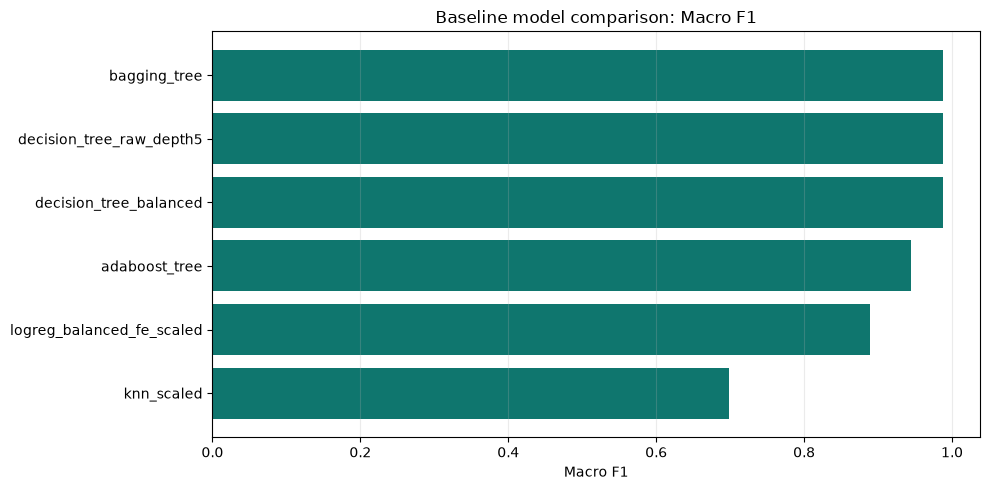

In [18]:
display(baseline_results.sort_values("f1_macro_mean", ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
base_plot = baseline_results.sort_values("f1_macro_mean")
ax.barh(base_plot["model_name"], base_plot["f1_macro_mean"], color="#0f766e")
ax.set_title("Baseline model comparison: Macro F1")
ax.set_xlabel("Macro F1")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا استنتجنا من الـ baselines؟

`decision_tree_raw_depth5` حقق `Macro F1 ≈ 0.9881` على الخصائص الأصلية فقط، وهذا رقم قريب جداً من النماذج الأقوى. هذه النتيجة كشفت أن جزءاً كبيراً من المشكلة قابل للتفسير بقواعد بسيطة، خصوصاً حول `f10`, `f14`, و`f12`.

لكن الـ ensemble النهائي بقي أعلى، خصوصاً في متوسط أداء الكلاسات الثلاثة. لذلك استخدمنا شجرة القرار كأداة فهم وتوثيق قوية، وليس كبديل نهائي عن ensemble.

</div>


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 11. تحليل شجرة القرار الخام والشرائح الصعبة

بعد أن ظهر أن شجرة قرار بسيطة على الخصائص الأصلية قوية جداً، حللناها بشكل منفصل. الهدف هنا ليس رفع التعقيد، بل فهم أين توجد الإشارة الحقيقية في الداتا.

أهمية الخصائص داخل الشجرة أوضحت أن `f10` و`f14` يملكان معظم القرار، ثم تأتي `f12` و`f9` بدرجة أقل. القواعد النصية للشجرة بينت أن `class1` و`class2` يظهران غالباً في مناطق محددة من `f10` و`f14` مع شروط إضافية على `f12` و`f9`.

بعد ذلك قسمنا بيانات التدريب إلى شرائح تشخيصية مثل `f10_high_q90`, و`f12_equals_0`, والصفوف ذات القيم الطرفية. بعد التحديث بقيت أصعب شريحة هي `f10_high_q90_and_f12_equals_0`، لكنها تحسنت مقارنة بالتشخيص السابق، وهذا يعني أن إدخال الشجرة الخام والـ ensemble الجديد ساعد فعلاً في جزء من المنطقة الصعبة.

</div>


Top raw DecisionTree features:


,feature,importance
0,f10,4.916990e-01
1,f14,4.894391e-01
2,f12,1.272063e-02
3,f9,3.706601e-03
4,f17,2.051282e-03
5,f1,3.427005e-04
6,f20,4.069746e-05
7,f5,8.586021e-16
8,f4,7.596235e-16
9,f2,0.000000e+00


Raw DecisionTree rules:
|--- f14 <= 0.06
|   |--- f10 <= 0.01
|   |   |--- class: class3
|   |--- f10 >  0.01
|   |   |--- f1 <= 0.84
|   |   |   |--- f20 <= 0.14
|   |   |   |   |--- class: class1
|   |   |   |--- f20 >  0.14
|   |   |   |   |--- f9 <= 0.06
|   |   |   |   |   |--- class: class3
|   |   |   |   |--- f9 >  0.06
|   |   |   |   |   |--- class: class1
|   |   |--- f1 >  0.84
|   |   |   |--- class: class3
|--- f14 >  0.06
|   |--- f10 <= 0.01
|   |   |--- f5 <= 0.50
|   |   |   |--- class: class3
|   |   |--- f5 >  0.50
|   |   |   |--- class: class3
|   |--- f10 >  0.01
|   |   |--- f12 <= 0.50
|   |   |   |--- f9 <= 0.15
|   |   |   |   |--- f17 <= 0.50
|   |   |   |   |   |--- class: class2
|   |   |   |   |--- f17 >  0.50
|   |   |   |   |   |--- class: class3
|   |   |   |--- f9 >  0.15
|   |   |   |   |--- f1 <= 0.22
|   |   |   |   |   |--- class: class3
|   |   |   |   |--- f1 >  0.22
|   |   |   |   |   |--- class: class3
|   |   |--- f12 >  0.50
|   |   |   |--

,slice,n_rows,class1_rows,class2_rows,class3_rows,accuracy,macro_f1,balanced_accuracy
5,f10_high_q90_and_f12_equals_0,277,83,173,21,0.981949,0.948121,0.920635
2,continuous_outlier_count_ge_1,286,53,9,224,0.993007,0.965172,0.997024
4,f10_high_q90,323,92,173,58,0.984520,0.978535,0.971264
7,f12_equals_0,2807,84,191,2532,0.998219,0.993152,0.999342
0,all_rows,3200,93,191,2916,0.998437,0.993570,0.999428
3,default_binary_pattern,1367,49,101,1217,0.997805,0.994711,0.999178
1,binary_pattern_distance_ge_3,51,2,4,45,1.000000,1.000000,1.000000
6,f10_low_q10,331,0,0,331,1.000000,1.000000,1.000000
8,f12_equals_1,393,9,0,384,1.000000,1.000000,1.000000


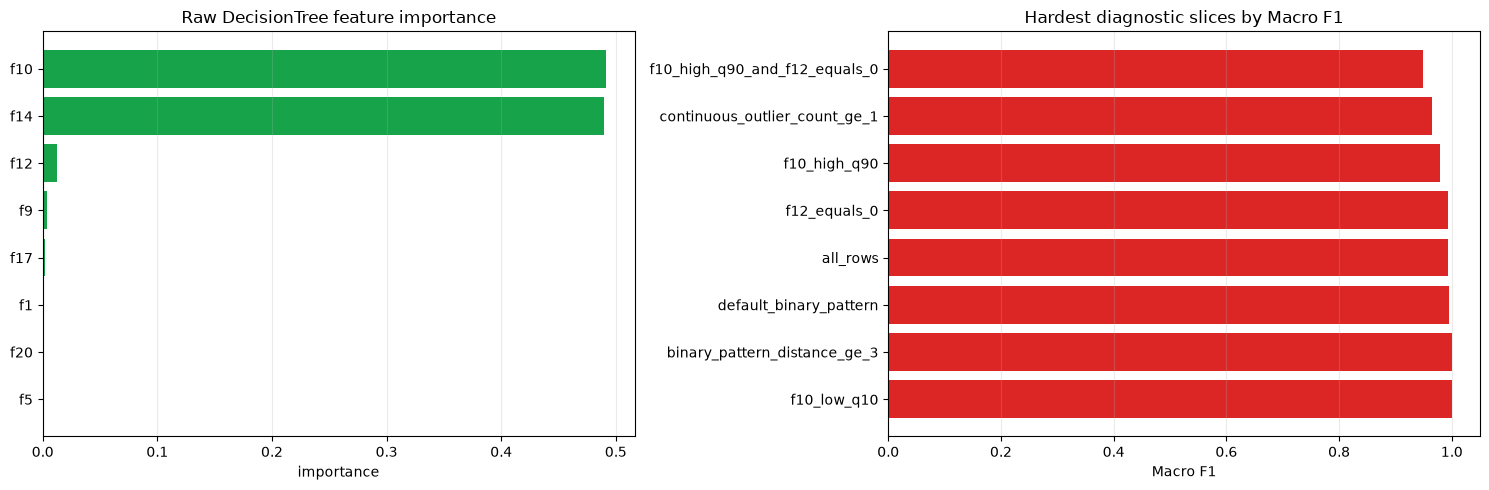

In [19]:
raw_tree_importance = pd.read_csv(ARTIFACT_DIR / "raw_decision_tree_feature_importance.csv")
slice_diagnostics = pd.read_csv(ARTIFACT_DIR / "slice_diagnostics.csv")

with open(ARTIFACT_DIR / "raw_decision_tree_rules.txt", "r", encoding="utf-8") as f:
    raw_tree_rules = f.read()

print("Top raw DecisionTree features:")
display(raw_tree_importance.head(10))

print("Raw DecisionTree rules:")
print(raw_tree_rules)

display(slice_diagnostics.sort_values("macro_f1"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
imp_plot = raw_tree_importance.head(8).iloc[::-1]
axes[0].barh(imp_plot["feature"], imp_plot["importance"], color="#16a34a")
axes[0].set_title("Raw DecisionTree feature importance")
axes[0].set_xlabel("importance")
axes[0].grid(axis="x", alpha=0.25)

slice_plot = slice_diagnostics.sort_values("macro_f1").head(8).iloc[::-1]
axes[1].barh(slice_plot["slice"], slice_plot["macro_f1"], color="#dc2626")
axes[1].set_title("Hardest diagnostic slices by Macro F1")
axes[1].set_xlabel("Macro F1")
axes[1].grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا استنتجنا من شجرة القرار والشرائح؟

شجرة القرار الخام أكدت أن `f10` و`f14` هما محور الفصل الأساسي بين الكلاسات، وهذا يطابق تحليل Mutual Information. وجود `f12` داخل قواعد الشجرة يوضح أن بعض الخصائص الثنائية لا تبدو قوية وحدها فقط، بل تصبح مهمة عندما تتفاعل مع حدود على `f10` و`f14`.

تحليل الشرائح بعد التحديث أظهر أن `f10_high_q90_and_f12_equals_0` ما زالت أصعب منطقة، حيث بقي `Macro F1` أقل من باقي الشرائح. هذا منطقي لأنها تحتوي نسبة كبيرة من `class1` و`class2` مقارنة بباقي الداتا.

التحسن في هذه المنطقة مهم، لكنه ليس كاملاً. لذلك احتفظنا بملف `oof_probability_audit.csv` حتى نستطيع لاحقاً دراسة الصفوف الصعبة بدقة أكبر بدل الاكتفاء بالمتوسط العام.

</div>


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 12. فحص ثبات النتائج عبر أكثر من تقسيم

أعدنا تقييم مجموعة أوسع من النماذج باستخدام أكثر من `random_state` في `StratifiedKFold`. هذه المرة لم نكتفِ بالنماذج القوية فقط، بل أضفنا DecisionTree وBagging ونماذج EDA features.

النتيجة الأهم أن `bagging_tree_original` كان الأقوى من ناحية متوسط `Macro F1` عبر seeds، وهذا يدعم فكرة أن بنية الأشجار الخام مناسبة جداً لهذه الداتا. كما أن `lightgbm_original` و`lightgbm_eda_fe` بقيا قريبين ومستقرين.

</div>


,model_name,f1_macro_mean_over_seeds,f1_macro_std_over_seeds,f1_macro_min_over_seeds,accuracy_mean_over_seeds,balanced_accuracy_mean_over_seeds
0,bagging_tree_original,0.990943,0.001494,0.989220,0.997812,0.999200
1,lightgbm_original,0.989764,0.003511,0.986767,0.997500,0.993324
2,lightgbm_eda_fe,0.988596,0.001366,0.987351,0.997083,0.998386
3,random_forest_original,0.987673,0.000977,0.986545,0.997292,0.992144
4,lightgbm_simple_fe,0.987162,0.001957,0.985121,0.996875,0.994277
5,decision_tree_raw_depth5,0.986031,0.002043,0.984070,0.997188,0.988398
6,gradient_boosting_fe,0.985604,0.003897,0.981139,0.996563,0.992278
7,hgb_simple_fe,0.983149,0.004266,0.978246,0.996354,0.985091
8,hgb_eda_fe,0.979490,0.003897,0.975645,0.995521,0.982458


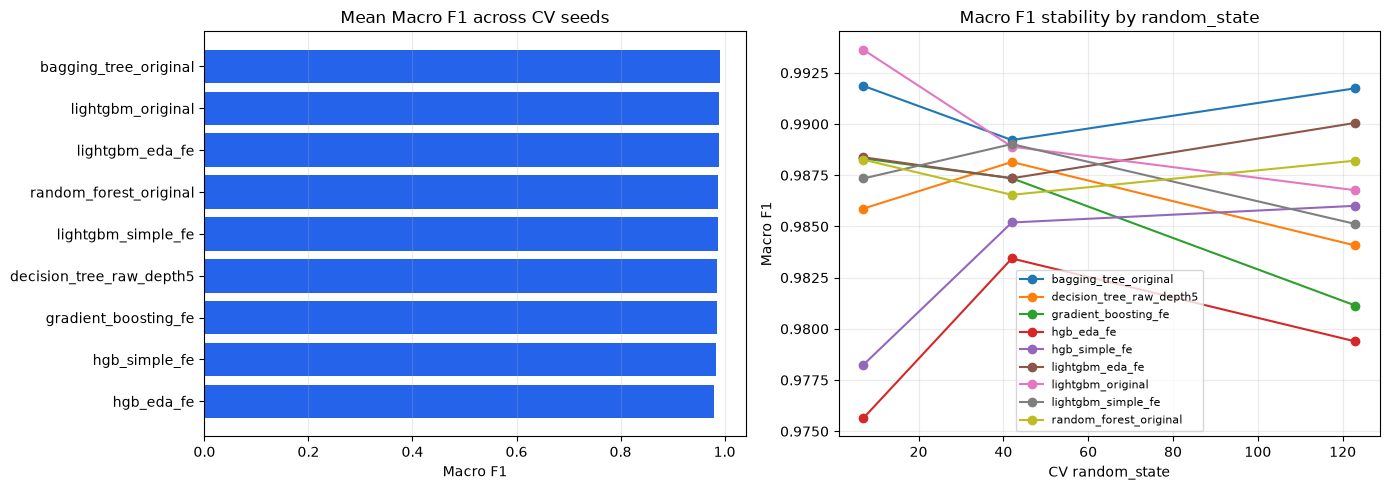

In [20]:
display(robust_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
robust_plot = robust_summary.sort_values("f1_macro_mean_over_seeds")
axes[0].barh(robust_plot["model_name"], robust_plot["f1_macro_mean_over_seeds"], color="#2563eb")
axes[0].set_title("Mean Macro F1 across CV seeds")
axes[0].set_xlabel("Macro F1")
axes[0].grid(axis="x", alpha=0.25)

for model_name, group in robust_by_seed.groupby("model_name"):
    axes[1].plot(group["random_state"], group["f1_macro_mean"], marker="o", label=model_name)
axes[1].set_title("Macro F1 stability by random_state")
axes[1].set_xlabel("CV random_state")
axes[1].set_ylabel("Macro F1")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا استنتجنا من فحص الثبات؟

فحص الثبات غيّر فهمنا قليلاً: لم يكن أفضل نموذج مستقر هو LightGBM فقط، بل ظهر `bagging_tree_original` كخيار قوي جداً عبر أكثر من split. هذا يبرر إدخاله كمرشح رسمي داخل ensemble.

في المقابل، بعض نماذج EDA features حسنت الفهم والتحليل لكنها لم تكن دائماً الأفضل كأداء منفرد. لذلك لم نعتمد عليها وحدها، بل تركنا الـ ensemble يقرر قيمتها من خلال الاحتمالات.

</div>


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 13. رسومات مقارنة الموديلات والـ Ensemble

الرسومات تلخص نتائج الجداول بصرياً. الرسم الأول يقارن `Macro F1` للنماذج الأساسية، والرسم الثاني يعرض أوزان الـ ensemble النهائي، ثم نعرض مصفوفة الالتباس من OOF predictions.

مصفوفة الالتباس مهمة لأنها تكشف نوع الأخطاء: هل الأخطاء تأتي من الكلاس الأكبر فقط، أم من الخلط بين `class1` و`class2`، أم من صفوف قليلة صعبة؟

</div>


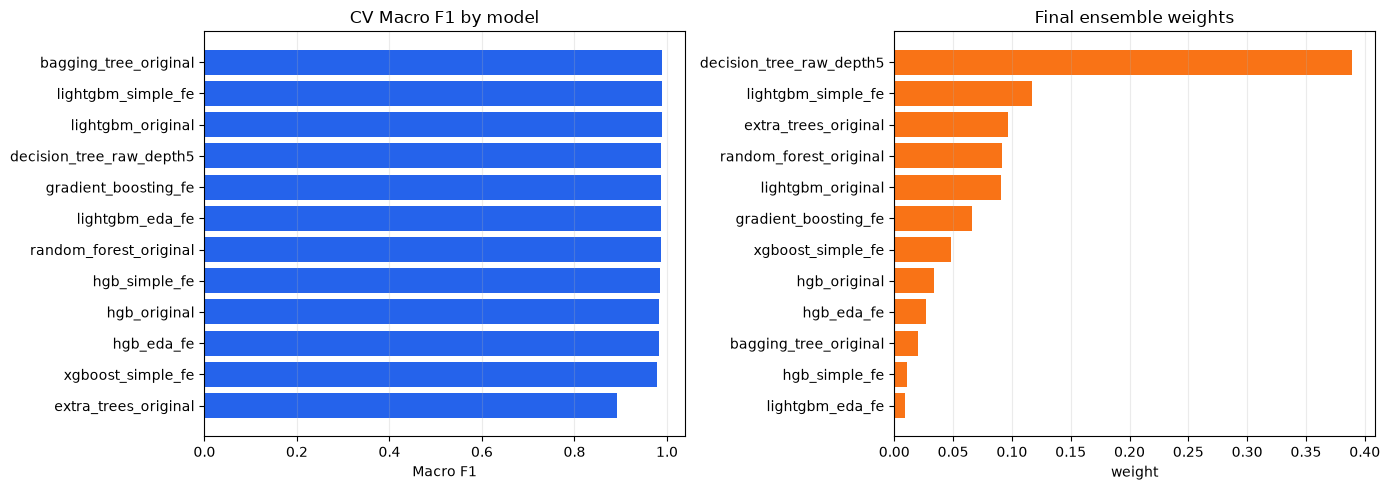

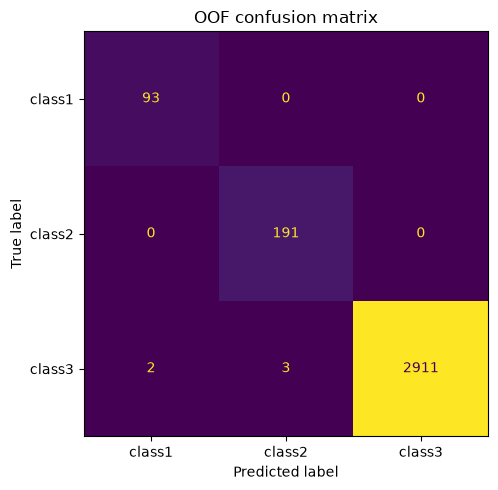

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = cv_results.sort_values("f1_macro_mean")
axes[0].barh(plot_df["model_name"], plot_df["f1_macro_mean"], color="#2563eb")
axes[0].set_title("CV Macro F1 by model")
axes[0].set_xlabel("Macro F1")
axes[0].grid(axis="x", alpha=0.25)

weights_df = pd.DataFrame(list(ensemble_info["weights"].items()), columns=["model", "weight"]).sort_values("weight")
axes[1].barh(weights_df["model"], weights_df["weight"], color="#f97316")
axes[1].set_title("Final ensemble weights")
axes[1].set_xlabel("weight")
axes[1].grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_df.values, display_labels=class_names).plot(ax=ax, values_format="d", colorbar=False)
ax.set_title("OOF confusion matrix")
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا استنتجنا من الرسومات؟

رسم المقارنة يوضح أن عدة نماذج أصبحت قريبة جداً في الأداء، خصوصاً النماذج المبنية على الأشجار. أوزان الـ ensemble بعد التحديث أظهرت اعتماداً واضحاً على `decision_tree_raw_depth5` مع مساهمة من LightGBM وRandom Forest وExtra Trees وبقية النماذج.

هذه التركيبة منطقية: شجرة القرار تلتقط القواعد الواضحة، بينما النماذج الأخرى تساعد في الحالات الأقل وضوحاً. مصفوفة الالتباس أظهرت أن `class1` و`class2` تم التقاطهما بالكامل في OOF، وبقيت الأخطاء الخمسة كلها من `class3` باتجاه الكلاسات الصغيرة.

</div>


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 14. فحص ملف الرفع

بعد توليد `submission.csv` فحصنا أن الملف مطابق لصيغة الرفع: عمود `ID` وعمود `target` فقط، وعدد الصفوف 3200، وترتيب الـ IDs مطابق لـ `sample_submission.csv`، ولا توجد قيم مفقودة في التنبؤات.

فحصنا أيضاً توزيع التنبؤات. الملف تنبأ بـ 81 صفاً `class1`، و188 صفاً `class2`، و2931 صفاً `class3`. هذا قريب من توزيع التدريب، لكنه ليس نسخة منه حرفياً؛ أي أن النموذج يغير قراره حسب خصائص test.

</div>


,ID,target
0,10000,class3
1,10001,class3
2,10002,class3
3,10003,class3
4,10004,class3


target
class1      80
class2     189
class3    2931
Name: count, dtype: int64

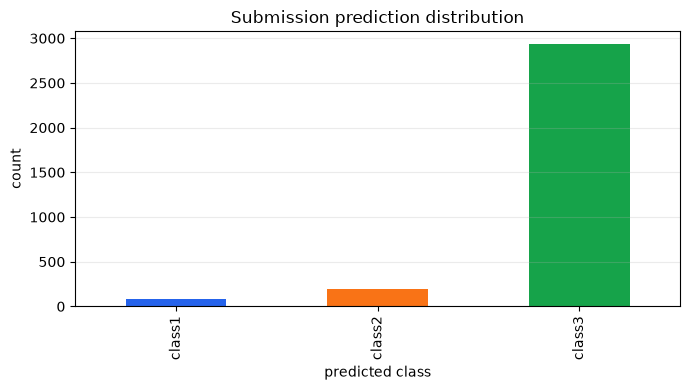

In [22]:
assert list(submission.columns) == [ID_COL, TARGET_COL]
assert submission[ID_COL].tolist() == sample_submission[ID_COL].tolist()
assert submission[TARGET_COL].notna().all()
assert set(submission[TARGET_COL].unique()).issubset(set(class_names))

display(submission.head())
display(submission[TARGET_COL].value_counts().sort_index().rename("count"))

fig, ax = plt.subplots(figsize=(7, 4))
submission[TARGET_COL].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#2563eb", "#f97316", "#16a34a"])
ax.set_title("Submission prediction distribution")
ax.set_xlabel("predicted class")
ax.set_ylabel("count")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### ماذا استنتجنا من ملف الرفع؟

ملف `submission.csv` جاهز من ناحية الشكل والمنهجية. التنبؤات ناتجة بالكامل من النماذج المدربة على `train_data.csv`، ولا يوجد تعديل يدوي على صفوف الاختبار.

توزيع التنبؤات منطقي مقارنة بتوزيع التدريب، وهذا يقلل خطر أن يكون النموذج منحازاً بشكل زائد لكلاس واحد أو أنه غيّر التوزيع بطريقة غير مبررة.

</div>


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 15. التعامل مع Public و Private

نتيجة Public leaderboard مفيدة كإشارة خارجية، لكنها لا تكفي وحدها لاختيار النموذج لأن جزءاً من الاختبار يبقى غير ظاهر حتى نهاية المسابقة.

لذلك اعتمدنا على تحقق داخلي متعدد: `StratifiedKFold`, `Macro F1`, مقارنة baselines، فحص الثبات عبر أكثر من split، وتحليل الشرائح الصعبة. بهذه الطريقة يصبح قرار اختيار النموذج مبنياً على قابلية التعميم، وليس على محاولة تحسين رقم Public فقط.

</div>


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 16. MLflow و DVC في المشروع

استخدمنا MLflow لتسجيل التجارب والمقاييس: اسم النموذج، إعدادات التقييم، Accuracy، Balanced Accuracy، وMacro F1. كما سجلنا تجربة الـ ensemble النهائي مع الأوزان والمخرجات، وحفظنا الموديل النهائي وملفات التقارير كـ artifacts.

واستخدمنا DVC لتتبع ملفات الداتا بدون رفع ملفات CSV الخام إلى GitHub. ملفات `.dvc` الصغيرة موجودة في المستودع، أما الداتا نفسها فمخزنة في Google Drive remote. بهذه الطريقة يستطيع أي عضو في الفريق استرجاع الداتا عبر `dvc pull` بدون تحميل الملفات الخام داخل Git.

</div>
